<a href="https://colab.research.google.com/github/ehas1/Statistical-Bias-in-ML/blob/main/LIME_and_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
! pip install lime
import lime.lime_tabular
import shap
! pip install scikit-learn
from sklearn.decomposition import PCA
import xgboost as xgb
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import os
import glob
import joblib
from pathlib import Path
import requests
from io import StringIO

# Visualization Settings
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Global Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f3f26033e690388396084f5cf22f296e61a28653b7106015e70b40d649c175e0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# Storage and Model Loading Setup
def setup_storage():
    """Set up storage access for model files."""
    # First try the local COMPAS_models directory in the current working directory
    models_dir = os.path.join(os.getcwd(), 'COMPAS_models')

    if not os.path.exists(models_dir):
        # Try home directory
        models_dir = os.path.join(os.path.expanduser('~'), 'Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models')

    # Create the models directory if it doesn't exist
    if not os.path.exists(models_dir):
        os.makedirs(models_dir)
        print(f"Created models directory at {models_dir}")

    print(f"Using models directory: {models_dir}")
    return models_dir

def find_latest_model(pattern: str, models_dir: str = None) -> str:
    """Find the most recent model file matching the given pattern."""
    # Try multiple possible paths
    colab_path = "/content/gdrive/MyDrive/COMPAS_models"
    local_path = os.path.join(os.path.expanduser('~'), 'COMPAS_models')
    current_dir_path = os.path.join(os.getcwd(), 'COMPAS_models')

    # Use provided models_dir, or try all possible paths
    search_paths = [p for p in [models_dir, colab_path, local_path, current_dir_path] if p]

    print(f"\nSearching for pattern: {pattern}")
    print("Checking directories:")

    for path in search_paths:
        print(f"Checking {path}...")
        if os.path.exists(path):
            print(f"Directory exists: {path}")
            # List all files in directory
            print("Files in directory:")
            for f in os.listdir(path):
                print(f"  - {f}")

            # Try to find matching files
            full_pattern = os.path.join(path, pattern)
            files = glob.glob(full_pattern)
            if files:
                print(f"Found files matching {pattern}:")
                for f in files:
                    print(f"  - {f}")
                latest = max(files, key=os.path.getctime)
                print(f"Selected latest file: {latest}")
                # Check if it's a metadata file
                if 'metadata' in latest:
                    print("Warning: Selected file is a metadata file, skipping...")
                    continue
                return latest
        else:
            print(f"Directory does not exist: {path}")

    raise FileNotFoundError(f"No model files found matching pattern: {pattern}")

def load_all_models() -> tuple:
    """Load all models including bias-specific decision trees."""
    try:
        models_dir = setup_storage()
        # Load bias-specific decision tree models
        sex_bias_model_path = find_latest_model('sex_bias_decision_tree_model_*[!metadata].joblib')
        racial_bias_model_path = find_latest_model('racial_bias_decision_tree_model_*[!metadata].joblib')

        # Try to find XGBoost model with different possible extensions
        try:
            xgb_model_path = find_latest_model('xgboost_model_*[!metadata].ubj')
        except FileNotFoundError:
            try:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].json')
            except FileNotFoundError:
                xgb_model_path = find_latest_model('xgboost_model_*[!metadata].*')

        nn_model_path = find_latest_model('neural_network_model_*.keras')

        print("Loading models from:")
        print(f"Sex Bias Decision Tree: {sex_bias_model_path}")
        print(f"Racial Bias Decision Tree: {racial_bias_model_path}")
        print(f"XGBoost: {xgb_model_path}")
        print(f"Neural Network: {nn_model_path}")

        # Load decision tree models
        sex_bias_model = joblib.load(sex_bias_model_path)
        racial_bias_model = joblib.load(racial_bias_model_path)
        print("Successfully loaded bias-specific decision tree models")

        # Load XGBoost model
        try:
            wrapped_xgb = xgb.XGBClassifier(
                objective='binary:logistic',
                use_label_encoder=False
            )
            wrapped_xgb.load_model(str(xgb_model_path))
            print("Successfully loaded XGBoost model")
        except Exception as e:
            print(f"Error loading XGBoost model: {str(e)}")
            try:
                print("Attempting alternative loading method...")
                booster = xgb.Booster()
                booster.load_model(str(xgb_model_path))
                wrapped_xgb = xgb.XGBClassifier(
                    objective='binary:logistic',
                    use_label_encoder=False
                )
                wrapped_xgb._Booster = booster
                wrapped_xgb.n_classes_ = 2
                print("Successfully loaded XGBoost model using alternative method")
            except Exception as e2:
                print(f"Alternative loading method also failed: {str(e2)}")
                raise

        # Load Neural Network model
        nn_model = load_model(nn_model_path)
        print("Successfully loaded Neural Network model")

        return sex_bias_model, racial_bias_model, wrapped_xgb, nn_model

    except Exception as e:
        print(f"Error loading models: {str(e)}")
        print("Please ensure the models are saved in either:")
        print("- Google Colab: /content/drive/MyDrive/COMPAS_models/")
        print(f"- Local: {os.path.join(os.path.expanduser('~'), 'COMPAS_models')}")
        raise

# Mount Google Drive to access models
from google.colab import drive
drive.mount('/content/gdrive')
print("Google Drive mounted.")


# Set up storage and update the global models directory
MODELS_DIR = setup_storage()

# Load all models
sex_bias_model, racial_bias_model, xgb_model, nn_model = load_all_models()

# Create models dictionary
models_dict = {
    'sex_bias_dt': sex_bias_model,
    'racial_bias_dt': racial_bias_model,
    'xgb': xgb_model,
    'nn': nn_model
}

Mounted at /content/gdrive
Google Drive mounted.
Created models directory at /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models
Using models directory: /root/Desktop/OAIP/Statistical-Bias-in-ML/COMPAS_models

Searching for pattern: sex_bias_decision_tree_model_*[!metadata].joblib
Checking directories:
Checking /content/gdrive/MyDrive/COMPAS_models...
Directory exists: /content/gdrive/MyDrive/COMPAS_models
Files in directory:
  - decision_tree_model_20250806_005108.joblib
  - decision_tree_model_20250806_005108_metadata.json
  - racial_bias_decision_tree_model_20251014_202335.joblib
  - racial_bias_decision_tree_model_20251014_202335_metadata.json
  - sex_bias_decision_tree_model_20251014_202336.joblib
  - sex_bias_decision_tree_model_20251014_202336_metadata.json
  - xgboost_model_20251014_202340.joblib
  - xgboost_model_20251014_202340_metadata.json
  - neural_network_model_20251014_202649.keras
  - n

In [3]:
# Data Loading and Preprocessing Functions
def load_data(url="https://raw.githubusercontent.com/propublica/compas-analysis/refs/heads/master/cox-violent-parsed.csv"):
    """Load the COMPAS dataset from ProPublica's repository."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = pd.read_csv(StringIO(response.text))
        print(f"Successfully loaded data with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {str(e)}")
        raise

def preprocess_data(data):
    """Preprocess the COMPAS dataset for model interpretation."""
    # Print available columns for debugging
    print("Available columns in dataset:", data.columns.tolist())

    # Define required columns and their expected categories
    required_features = [
        'age',
        'c_charge_degree',
        'race',
        'sex',
        'priors_count',
        'juv_other_count',
        'juv_fel_count',
        'juv_misd_count',
        'decile_score'
    ]
    target = 'is_recid'

    # Define expected categories for categorical variables
    expected_categories = {
        'c_charge_degree': ['F', 'M'],  # Felony and Misdemeanor
        'race': ['African-American', 'Caucasian', 'Hispanic', 'Other'],
        'sex': ['Female', 'Male']
    }

    # Define the exact expected feature set for the neural network (14 features)
    expected_features = [
        # Numerical features
        'age', 'priors_count',
        # Charge degree features (all categories)
        'c_charge_degree_F', 'c_charge_degree_M',
        # Race features (all categories)
        'race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other',
        # Sex features (all categories)
        'sex_Female', 'sex_Male',
        # Additional features that might be expected by the model
        'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'decile_score'
    ]

    # Validate required columns exist
    missing_cols = [col for col in required_features + [target] if col not in data.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    # Preprocessing pipeline
    print("\nPreprocessing steps:")

    # 1. Handle missing values
    print("1. Handling missing values...")
    for col in required_features:
        if data[col].isnull().any():
            if pd.api.types.is_numeric_dtype(data[col]):
                data[col].fillna(data[col].mean(), inplace=True)
            else:
                data[col].fillna(data[col].mode()[0], inplace=True)

    # 2. Convert categorical variables with controlled encoding
    print("2. Converting categorical variables...")
    data_processed = data[required_features].copy()

    # Ensure categories are mapped correctly
    data_processed['race'] = data_processed['race'].map(lambda x: 'Other' if x not in expected_categories['race'] else x)
    data_processed['c_charge_degree'] = data_processed['c_charge_degree'].map(lambda x: 'F' if x not in expected_categories['c_charge_degree'] else x)
    data_processed['sex'] = data_processed['sex'].map(lambda x: 'Male' if x not in expected_categories['sex'] else x)

    # First handle numerical features
    numerical_features = ['age', 'priors_count', 'decile_score']

    # Create a new DataFrame with just numerical features
    data_processed_new = pd.DataFrame()

    # Add numerical features
    for feature in numerical_features:
        if feature in data.columns:
            data_processed_new[feature] = data[feature]
        else:
            print(f"Warning: {feature} not found in data, filling with zeros")
            data_processed_new[feature] = 0

    # Create dummy variables for categorical features
    for cat_col, categories in expected_categories.items():
        # Create dummy variables
        dummies = pd.get_dummies(
            data_processed[cat_col],
            prefix=cat_col,
            prefix_sep='_'
        )

        # Ensure all expected categories exist
        for category in categories:
            col_name = f"{cat_col}_{category}"
            if col_name not in dummies.columns:
                dummies[col_name] = 0

        # Add to processed data
        data_processed_new = pd.concat([data_processed_new, dummies], axis=1)

    # Ensure all expected features are present and in correct order
    missing_features = set(expected_features) - set(data_processed_new.columns)
    if missing_features:
        print(f"Warning: Adding missing features: {missing_features}")
        for feature in missing_features:
            data_processed_new[feature] = 0

    # Reorder columns to match expected feature order
    data_processed = data_processed_new[expected_features]

    print("\nVerifying features:")
    print(f"Expected features: {len(expected_features)}")
    print(f"Actual features: {len(data_processed.columns)}")
    print("\nFeatures in processed data:")
    for i, col in enumerate(data_processed.columns, 1):
        print(f"{i}. {col}")

    # Print the expected feature set
    print("\nFeature set after preprocessing:")
    print(data_processed.columns.tolist())

    # 3. Normalize numerical features
    print("3. Normalizing numerical features...")
    numerical_features = ['age', 'priors_count', 'decile_score']
    for col in numerical_features:
        data_processed[col] = (data_processed[col] - data_processed[col].mean()) / data_processed[col].std()

    # 4. Split into features and target
    print("4. Preparing train-test split...")
    # Convert to float32 for neural network compatibility
    X = data_processed.astype(np.float32)
    y = data[target]

    # Print feature columns for verification
    print("\nFeature columns after preprocessing:")
    print(X.columns.tolist())
    print(f"Number of features: {len(X.columns)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\nPreprocessing complete:")
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")

    return (X_train, y_train), (X_test, y_test)

# Load and preprocess data
print("Loading and preprocessing data...")
data = load_data()
(X_train, y_train), (X_test, y_test) = preprocess_data(data)
feature_names = X_train.columns.tolist()


Loading and preprocessing data...
Successfully loaded data with shape: (18316, 52)
Available columns in dataset: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event']

Preprocessing steps:
1. Handling missing values...
2. Converting categori

/tmp/ipython-input-86841138.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [4]:
# Load models and verify compatibility
def verify_model_compatibility(X_sample, models):
    """Verify that the preprocessed data matches the expected input shapes of the models."""
    print("Verifying model compatibility...")

    # Get the number of features in the preprocessed data
    n_features = X_sample.shape[1]
    print(f"\nPreprocessed data has {n_features} features")
    print(f"Input data types:")
    for col in X_sample.columns:
        print(f"  {col}: {X_sample[col].dtype}")

    # Convert data to numpy array and ensure float32 type
    X_single = X_sample.values[:1].astype(np.float32)

    # Check Sex Bias Decision Tree model
    try:
        sex_bias_pred = models['sex_bias_dt'].predict_proba(X_single)
        print("✓ Sex Bias Decision Tree model compatible")
        print(f"Sex Bias model prediction shape: {sex_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Sex Bias Decision Tree model error: {str(e)}")

    # Check Racial Bias Decision Tree model
    try:
        racial_bias_pred = models['racial_bias_dt'].predict_proba(X_single)
        print("✓ Racial Bias Decision Tree model compatible")
        print(f"Racial Bias model prediction shape: {racial_bias_pred.shape}")
    except Exception as e:
        print(f"✗ Racial Bias Decision Tree model error: {str(e)}")

    # Check XGBoost model
    try:
        xgb_pred = models['xgb'].predict_proba(X_single)
        print("✓ XGBoost model compatible")
        print(f"XGBoost prediction shape: {xgb_pred.shape}")
    except Exception as e:
        print(f"✗ XGBoost model error: {str(e)}")

    # Check Neural Network model
    try:
        # Get input shape from the model's input layer
        nn_input_shape = models['nn'].input_shape[1]
        print(f"\nNeural Network expects {nn_input_shape} features")
        if nn_input_shape != n_features:
            print(f"✗ Neural Network input shape mismatch: expected {nn_input_shape}, got {n_features}")
            print("\nFeature columns in preprocessed data:")
            print(X_sample.columns.tolist())
            raise ValueError(f"Neural Network expects {nn_input_shape} features but got {n_features}")

        # Try prediction with proper data type
        nn_pred = models['nn'].predict(X_single)
        print("✓ Neural Network model compatible")
        print(f"Neural Network prediction shape: {nn_pred.shape}")
    except Exception as e:
        print(f"✗ Neural Network model error: {str(e)}")
        print("\nDebug information:")
        print(f"Input shape: {X_single.shape}")
        print(f"Input data type: {X_single.dtype}")
        print(f"Model summary:")
        models['nn'].summary()
        raise

# Verify compatibility of all models
print("Verifying model compatibility...")
verify_model_compatibility(X_train, models_dict)


Verifying model compatibility...
Verifying model compatibility...

Preprocessed data has 14 features
Input data types:
  age: float32
  priors_count: float32
  c_charge_degree_F: float32
  c_charge_degree_M: float32
  race_African-American: float32
  race_Caucasian: float32
  race_Hispanic: float32
  race_Other: float32
  sex_Female: float32
  sex_Male: float32
  juv_fel_count: float32
  juv_misd_count: float32
  juv_other_count: float32
  decile_score: float32
✓ Sex Bias Decision Tree model compatible
Sex Bias model prediction shape: (1, 2)
✓ Racial Bias Decision Tree model compatible
Racial Bias model prediction shape: (1, 2)
✓ XGBoost model compatible
XGBoost prediction shape: (1, 2)

Neural Network expects 14 features


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
✓ Neural Network model compatible
Neural Network prediction shape: (1, 1)


In [5]:
# LIME and SHAP Setup Functions
def setup_explainers(X_train, feature_names, models):
    """Set up LIME and SHAP explainers for all models"""
    # LIME explainer setup
    # Since data is already one-hot encoded and normalized, treat features as numerical for LIME
    # Remove categorical_features and categorical_names to avoid errors with one-hot encoded data
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values,
        feature_names=feature_names,
        class_names=['No Recidivism', 'Recidivism'],
        mode='classification',
        discretize_continuous=False,  # Don't discretize since we've already normalized
        sample_around_instance=False,  # Don't sample around instance to avoid scale issues
        kernel_width=0.75 * np.sqrt(X_train.shape[1]),  # Scale kernel width with feature count
        verbose=False
    )

    # SHAP explainers
    def nn_predict_wrapper(x):
        pred = models['nn'].predict(x.astype(np.float32))
        if pred.shape[1] == 1:
            # If single output, convert to two-class probability
            return np.hstack([1 - pred, pred])
        return pred

    shap_exp = {
        'sex_bias_dt': shap.TreeExplainer(models['sex_bias_dt']),
        'racial_bias_dt': shap.TreeExplainer(models['racial_bias_dt']),
        'xgb': shap.TreeExplainer(models['xgb']),
        'nn': shap.KernelExplainer(
            nn_predict_wrapper,
            shap.sample(X_train, 100, random_state=42),
            link="logit"
        )
    }

    return lime_exp, shap_exp

def plot_global_importance(X_train, lime_exp, shap_exp, models, feature_names, focus_bias=None):
    """
    Plot global feature importance using LIME and SHAP

    Parameters:
    -----------
    focus_bias : str, optional
        Can be 'sex', 'racial', or None. If specified, highlights features related to that type of bias.
    """
    # Define bias-related features
    sex_bias_features = ['sex_Female', 'sex_Male']
    racial_bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']

    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    title = 'Global Feature Importance Comparison'
    if focus_bias:
        title += f' (Focus on {focus_bias.capitalize()} Bias)'
    fig.suptitle(title, fontsize=14)

    # SHAP importance
    plt.sca(axes[0])
    shap_values = {}
    for name, explainer in shap_exp.items():
        if focus_bias:
            if focus_bias == 'sex' and 'racial_bias' in name:
                continue
            if focus_bias == 'racial' and 'sex_bias' in name:
                continue

        data = X_train if name != 'nn' else shap.sample(X_train, 100)
        values = explainer.shap_values(data)
        if isinstance(values, list):
            values = values[1]
        shap_values[name] = np.abs(values).mean(0)

    # Plot SHAP importance with highlighting
    shap_df = pd.DataFrame(shap_values, index=feature_names)
    ax = shap_df.plot(kind='bar', ax=axes[0])
    axes[0].set_title('SHAP Global Feature Importance')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Mean |SHAP value|')

    # Highlight bias-related features
    if focus_bias:
        highlight_features = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        for i, feature in enumerate(feature_names):
            if feature in highlight_features:
                ax.patches[i].set_facecolor('red')
                ax.patches[i].set_alpha(0.7)

    # LIME importance
    X_sample = X_train.sample(n=100, random_state=42)
    lime_values = {name: np.zeros(len(feature_names)) for name in models if not focus_bias or
                  (focus_bias == 'sex' and 'racial_bias' not in name) or
                  (focus_bias == 'racial' and 'sex_bias' not in name)}

    for x in X_sample.values:
        for name, model in models.items():
            if name not in lime_values:
                continue
            predict_fn = model.predict_proba if name != 'nn' else model.predict
            exp = lime_exp.explain_instance(x, predict_fn, num_features=len(feature_names))
            for feat, imp in exp.as_list():
                # Use regex to extract feature name, handling potential < or > signs and numerical values
                match = re.match(r'([a-zA-Z_]+)', feat)
                if match:
                  fname = match.group(1)
                  if fname in feature_names:
                      idx = feature_names.index(fname)
                      lime_values[name][idx] += abs(imp)


    # Plot LIME importance with highlighting
    lime_df = pd.DataFrame(lime_values, index=feature_names)
    ax = lime_df.plot(kind='bar', ax=axes[1])
    axes[1].set_title('LIME Global Feature Importance')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Cumulative |importance|')

    # Highlight bias-related features
    if focus_bias:
        highlight_features = sex_bias_features if focus_bias == 'sex' else racial_bias_features
        for i, feature in enumerate(feature_names):
            if feature in highlight_features:
                ax.patches[i].set_facecolor('red')
                ax.patches[i].set_alpha(0.7)

    plt.tight_layout()
    plt.show()

def analyze_bias_impact(X_test, y_test, models, feature_names, bias_type='sex'):
    """
    Analyze the impact of bias-related features on model predictions

    Parameters:
    -----------
    bias_type : str
        Either 'sex' or 'racial'
    """
    # Select relevant features and model based on bias type
    if bias_type == 'sex':
        bias_features = ['sex_Female', 'sex_Male']
        bias_model = models['sex_bias_dt']
        model_name = 'Sex Bias DT'
    else:
        bias_features = ['race_African-American', 'race_Caucasian', 'race_Hispanic', 'race_Other']
        bias_model = models['racial_bias_dt']
        model_name = 'Racial Bias DT'

    # Get feature indices
    bias_indices = [feature_names.index(f) for f in bias_features]

    # Make predictions
    y_pred = bias_model.predict(X_test)

    # Calculate overall metrics
    from sklearn.metrics import classification_report, confusion_matrix
    print(f"\nModel Performance Analysis ({model_name}):")
    print("-" * 50)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Analyze predictions by protected attributes
    print(f"\nPrediction Distribution by {bias_type.capitalize()} Categories:")
    for feature in bias_features:
        feature_idx = feature_names.index(feature)
        subset_mask = X_test.iloc[:, feature_idx] == 1
        subset_pred = y_pred[subset_mask]
        subset_true = y_test[subset_mask]

        print(f"\n{feature} Analysis:")
        print(f"Total samples: {len(subset_pred)}")
        print(f"Predicted recidivism rate: {(subset_pred == 1).mean():.3f}")
        print(f"Actual recidivism rate: {(subset_true == 1).mean():.3f}")
        print("\nConfusion Matrix:")
        print(confusion_matrix(subset_true, subset_pred))

# Initialize explainers
print("Setting up LIME and SHAP explainers...")
lime_exp, shap_exp = setup_explainers(X_train, feature_names, models_dict)

# Print available models for analysis
print("\nAvailable models for analysis:")
for model_name in models_dict.keys():
    print(f"- {model_name}")

Setting up LIME and SHAP explainers...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  

Available models for analysis:
- sex_bias_dt
- racial_bias_dt
- xgb
- nn


# LIME vs. SHAP Individual Instances


Analyzing 5 random instances...

Instance 2144 (True label: No Recidivism)

Actual dataset values:
id                                                  1293
name                                      zachary whalen
first                                            zachary
last                                              whalen
compas_screening_date                         2014-03-29
sex                                                 Male
dob                                           1991-09-03
age                                                   24
age_cat                                     Less than 25
race                                    African-American
juv_fel_count                                          0
decile_score                                           5
juv_misd_count                                         1
juv_other_count                                        0
priors_count                                           5
days_b_screening_arrest                      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda77c9490>, 'local_exp': {1: [(np.int64(6), np.float64(0.020685077094057182)), (np.int64(0), np.float64(-0.0023972912382276743)), (np.int64(4), np.float64(0.0008783218373054037)), (np.int64(2), np.float64(0.0008207574680542346)), (np.int64(3), np.float64(0.0007565351292306925)), (np.int64(5), np.float64(0.0006441885781528431))]}, 'intercept': {1: np.float64(0.3506892727479256)}, 'score': 0.17527825735986757, 'local_pred': array([0.33905292]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.66001248, 0.33998752])}
SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda77c95b0>, 'local_exp': {1: [(np.int64(0), np.float64(-0.06889779757998193)), (np.int64(4), np.float64(0.05993315153989087)), (np.int64(3), np.float64(0.025006532836897306)), (np.int64(9), np.float64(-0.0034796980597967524)), (np.int64(1), np.float64(0.0026631765756571163)), (np.int64(10), np.float64(0.0016327270186967974))]}, 'intercept': {1: np.float64(0.5839439630274013)}, 'score': 0.46524214082557425, 'local_pred': array([0.3587023]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.74153319, 0.25846681])}
SHAP values shape: (1, 14, 2)
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda4ed3b90>, 'local_exp': {1: [(np.int64(4), np.float64(0.04006666768777423)), (np.int64(0), np

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
SHAP values shape: (1, 14, 2)


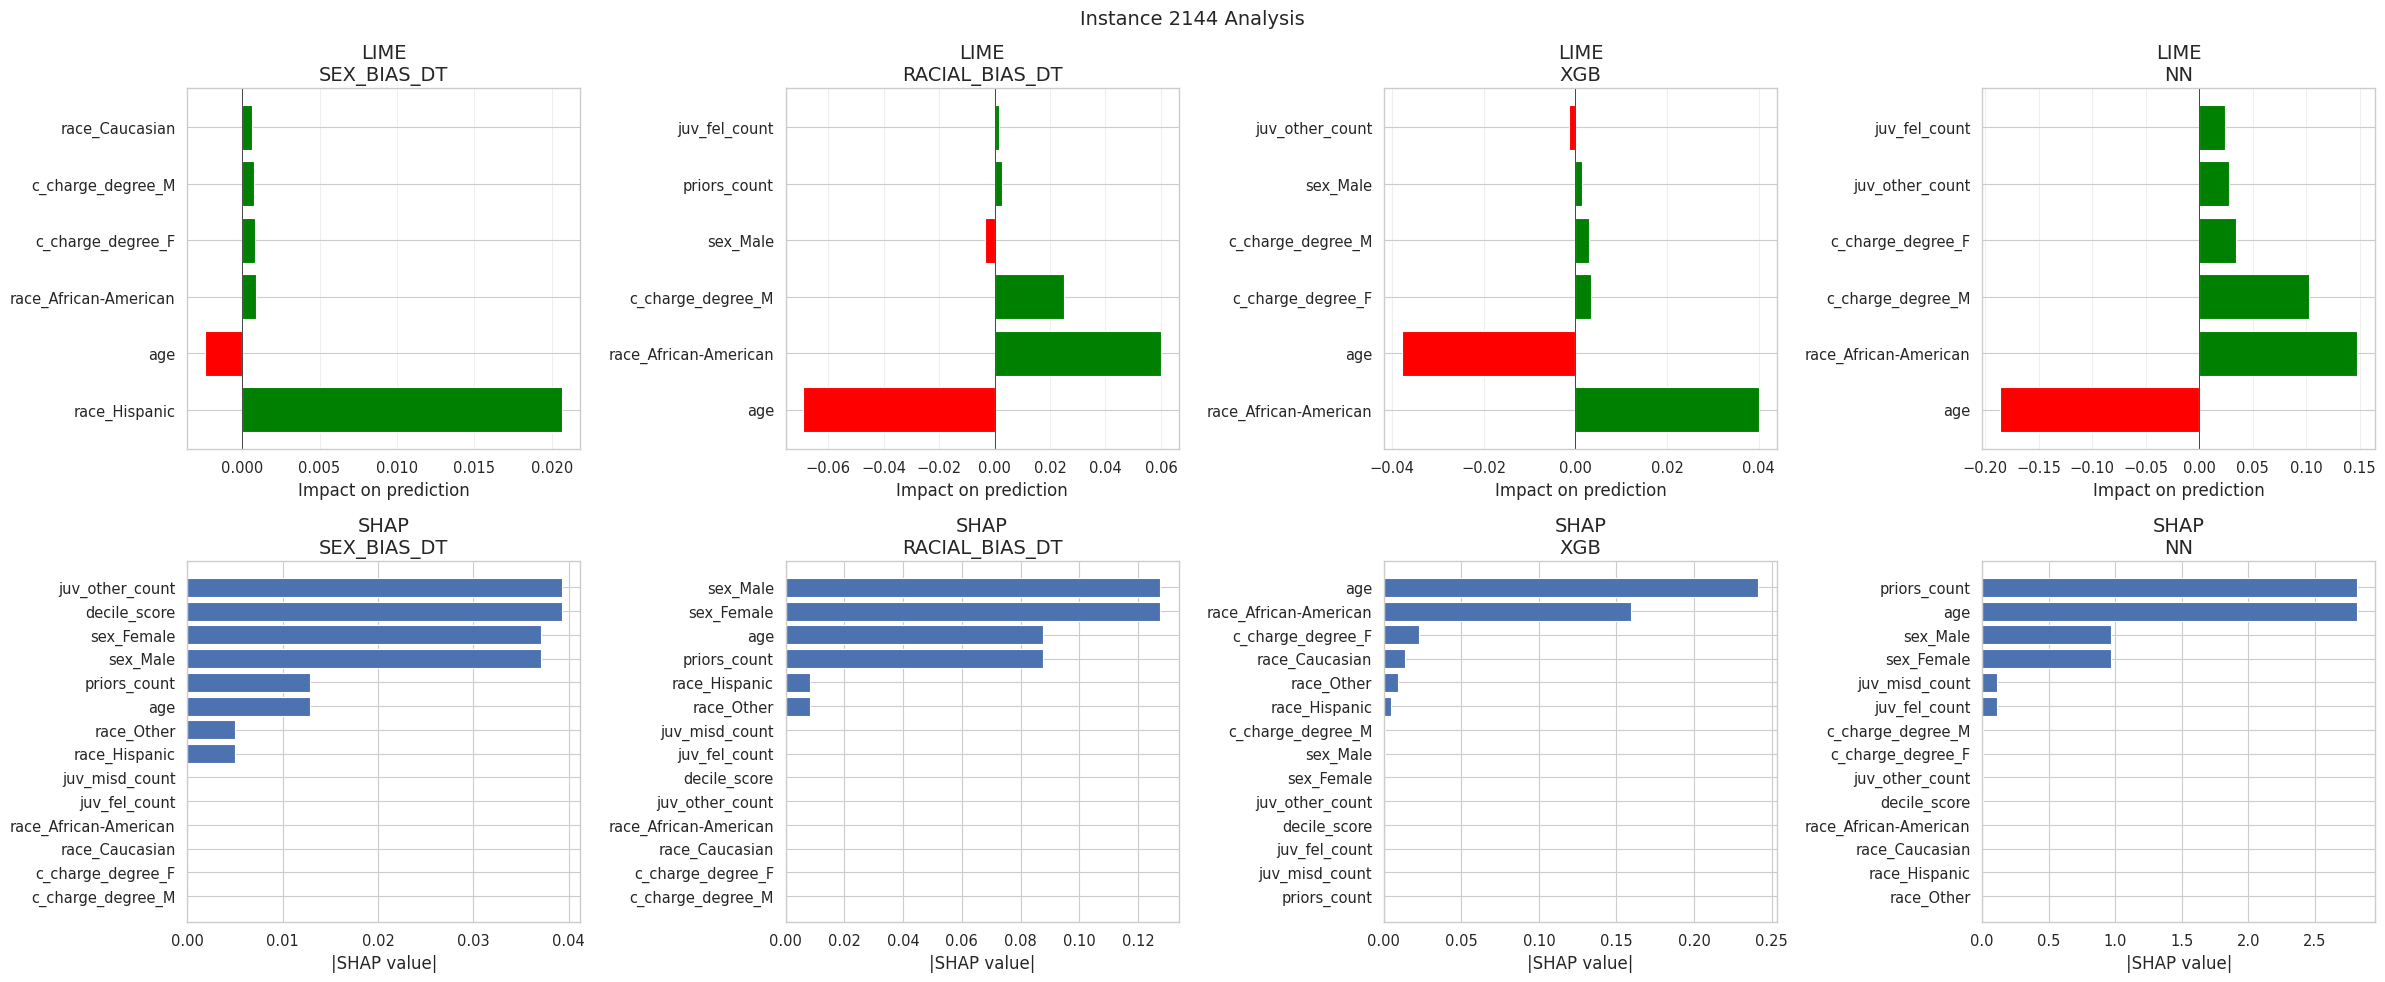


Instance 2596 (True label: No Recidivism)

Actual dataset values:
id                                          1566
name                               ulysses davis
first                                    ulysses
last                                       davis
compas_screening_date                 2013-11-19
sex                                         Male
dob                                   1959-05-04
age                                           56
age_cat                          Greater than 45
race                            African-American
juv_fel_count                                  0
decile_score                                   3
juv_misd_count                                 0
juv_other_count                                0
priors_count                                   8
days_b_screening_arrest                   -106.0
c_jail_in                    2013-08-05 07:30:16
c_jail_out                   2013-10-16 11:44:03
c_case_number                      08021349CF10A
c_

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.375
XGB             : 0.494
NN              : 0.674


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda75799a0>, 'local_exp': {1: [(np.int64(6), np.float64(0.02303275627070366)), (np.int64(0), np.float64(-0.0036312575508531913)), (np.int64(4), np.float64(0.002391983182906035)), (np.int64(3), np.float64(0.0014599658165097783)), (np.int64(10), np.float64(-0.0009764122481744675)), (np.int64(9), np.float64(0.0004543338256583996))]}, 'intercept': {1: np.float64(0.35131705208258385)}, 'score': 0.17037262710959222, 'local_pred': array([0.34221703]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.66001248, 0.33998752])}
SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda6b700e0>, 'local_exp': {1: [(np.int64(0), np.float64(-0.06334614564881036)), (np.int64(4), np.float64(0.05415524447321601)), (np.int64(3), np.float64(0.0316204885898591)), (np.int64(7), np.float64(0.004009502299158925)), (np.int64(9), np.float64(0.0021813004310731222)), (np.int64(12), np.float64(-0.0018346466991451382))]}, 'intercept': {1: np.float64(0.5842477169262821)}, 'score': 0.4432616421322003, 'local_pred': array([0.52632191]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.62535788, 0.37464212])}
SHAP values shape: (1, 14, 2)
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda6bd6cf0>, 'local_exp': {1: [(np.int64(4), np.float64(0.03815265363646136)), (np.int64(0), np.fl

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
SHAP values shape: (1, 14, 2)


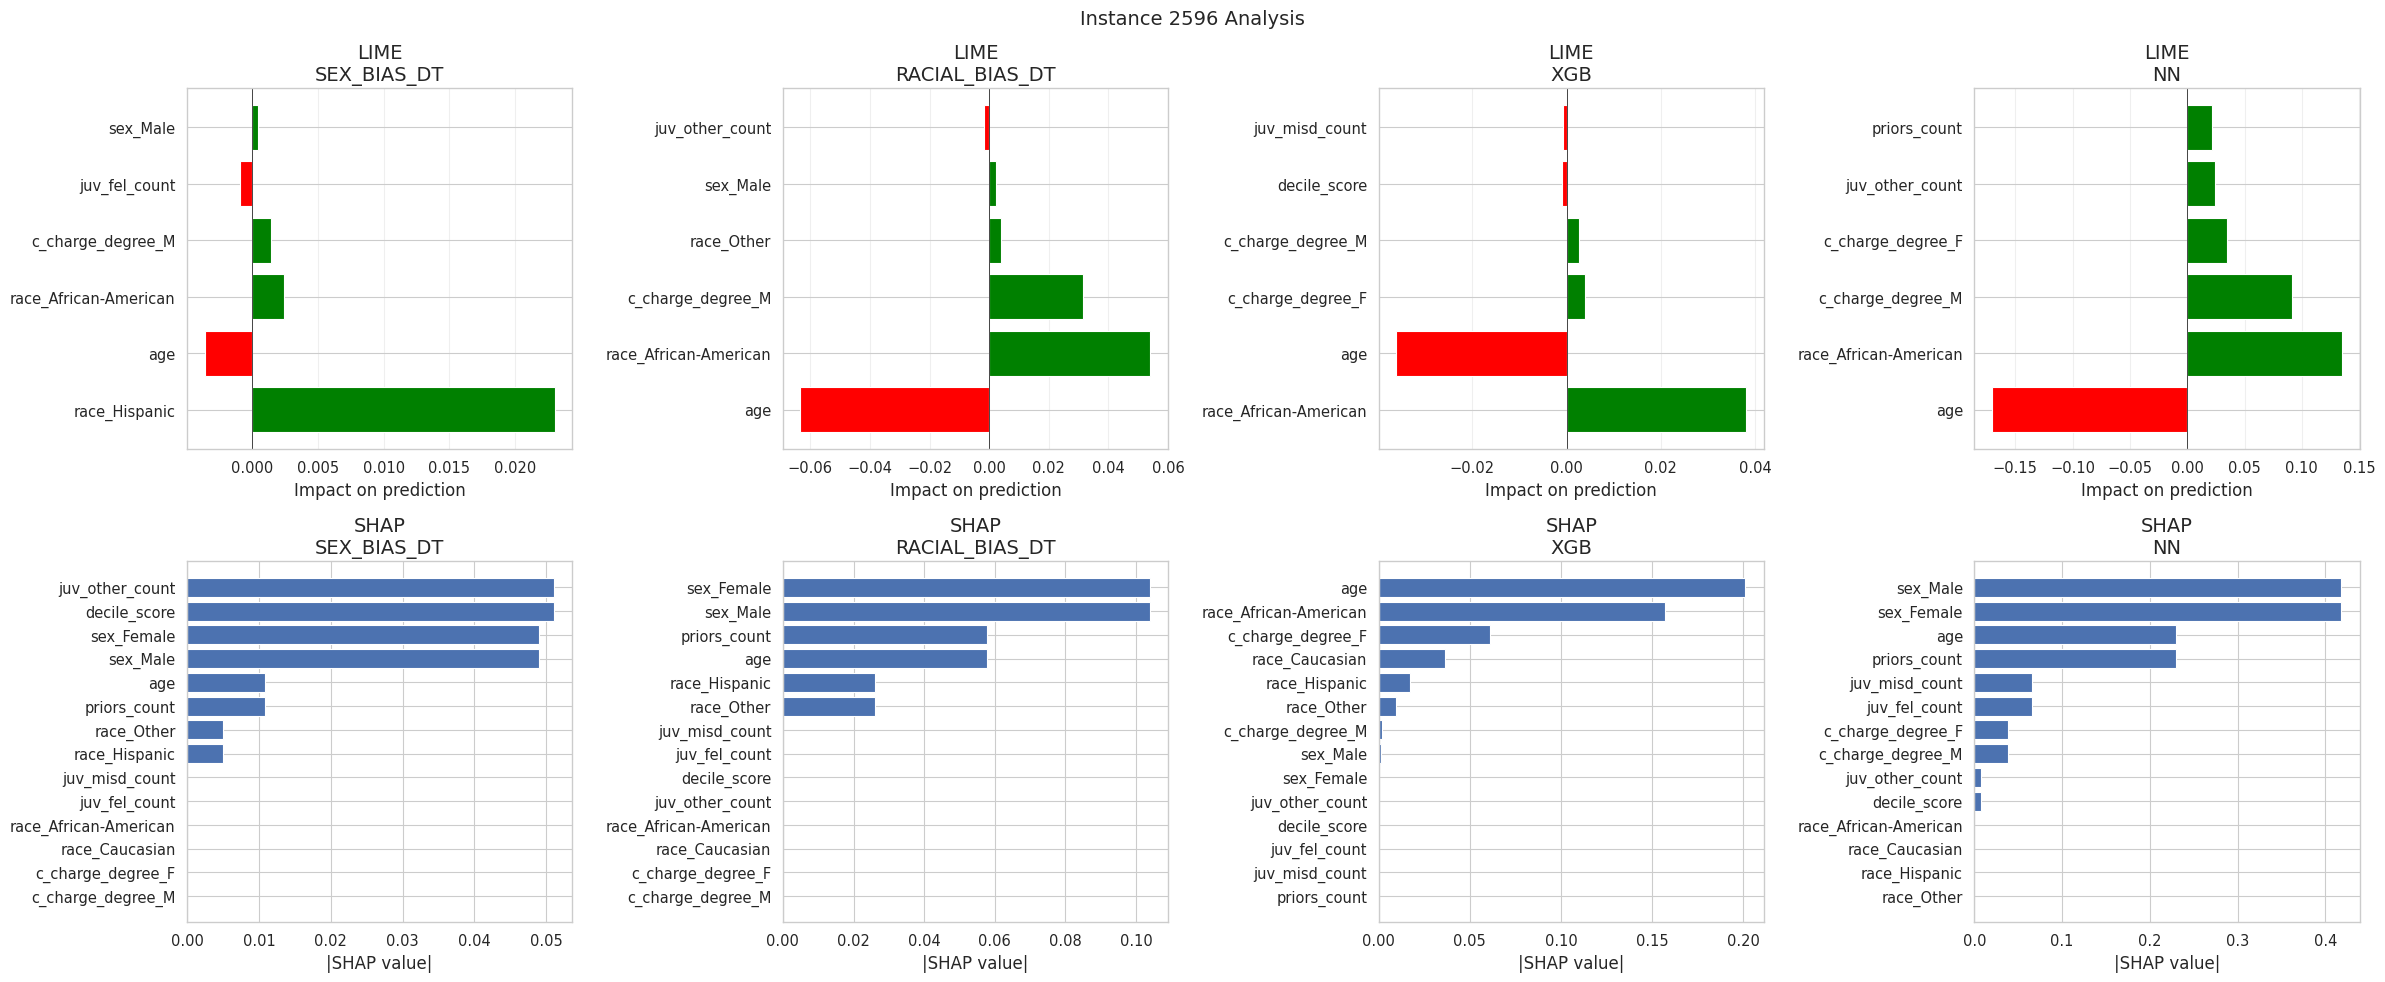


Instance 2024 (True label: Recidivism)

Actual dataset values:
id                                       1224
name                           stanley blaise
first                                 stanley
last                                   blaise
compas_screening_date              2014-11-29
sex                                      Male
dob                                1982-09-05
age                                        33
age_cat                               25 - 45
race                         African-American
juv_fel_count                               0
decile_score                                3
juv_misd_count                              0
juv_other_count                             0
priors_count                                0
days_b_screening_arrest                   NaN
c_jail_in                                 NaN
c_jail_out                                NaN
c_case_number                             NaN
c_offense_date                            NaN
c_arrest_date   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



Debug - Prediction shapes:
Sex Bias DT pred shape: (1, 2)
Racial Bias DT pred shape: (1, 2)
XGB pred shape: (1, 2)
NN pred shape: (1, 1)

Predictions:
----------------------------------------
SEX_BIAS_DT     : 0.340
RACIAL_BIAS_DT  : 0.511
XGB             : 0.508
NN              : 0.782


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda68980e0>, 'local_exp': {1: [(np.int64(6), np.float64(0.024545783991622345)), (np.int64(0), np.float64(-0.003566777729366268)), (np.int64(4), np.float64(0.003161349392531776)), (np.int64(2), np.float64(0.0010894653815802992)), (np.int64(1), np.float64(0.001073709436103558)), (np.int64(12), np.float64(-0.0007658873991812985))]}, 'intercept': {1: np.float64(0.35251065157897843)}, 'score': 0.1840984872755973, 'local_pred': array([0.34306153]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.66001248, 0.33998752])}
SHAP values shape: (1, 14, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda481e120>, 'local_exp': {1: [(np.int64(0), np.float64(-0.0669282479036411)), (np.int64(4), np.float64(0.052455532914615084)), (np.int64(3), np.float64(0.029822676917676077)), (np.int64(7), np.float64(0.00498944190019308)), (np.int64(12), np.float64(0.00331107512945976)), (np.int64(9), np.float64(0.002711179574461814))]}, 'intercept': {1: np.float64(0.5868246659294678)}, 'score': 0.4451068136058902, 'local_pred': array([0.57461125]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.48877072, 0.51122928])}
SHAP values shape: (1, 14, 2)
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda4841fd0>, 'local_exp': {1: [(np.int64(4), np.float64(0.03703440433761838)), (np.int64(0), np.float

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
SHAP values shape: (1, 14, 2)


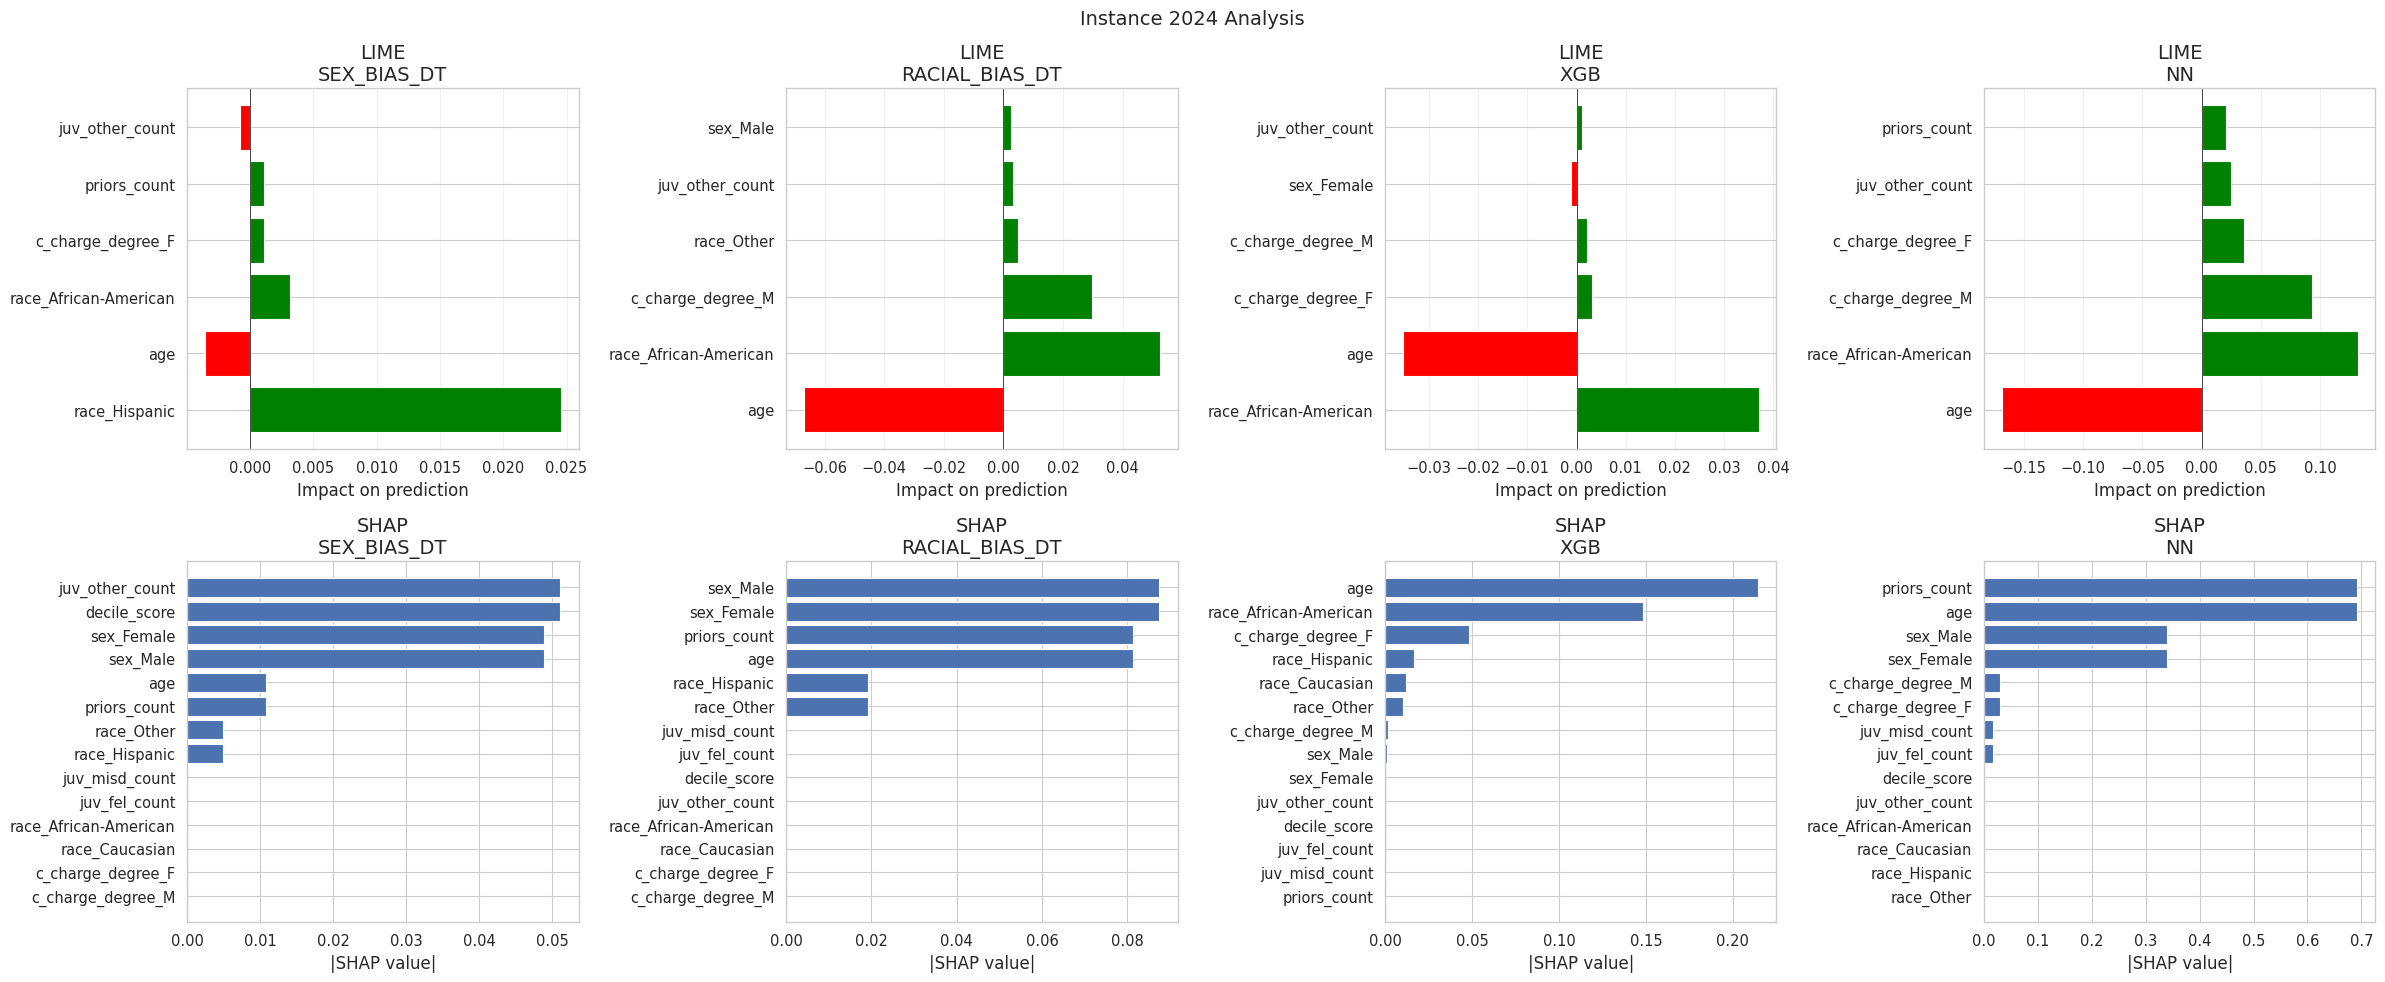


Instance 2646 (True label: Recidivism)

Actual dataset values:
id                                        1601
name                             russell adams
first                                  russell
last                                     adams
compas_screening_date               2013-05-08
sex                                       Male
dob                                 1983-11-10
age                                         32
age_cat                                25 - 45
race                                 Caucasian
juv_fel_count                                0
decile_score                                 2
juv_misd_count                               0
juv_other_count                              0
priors_count                                 2
days_b_screening_arrest                   -1.0
c_jail_in                  2013-05-07 02:17:32
c_jail_out                 2013-05-12 07:15:28
c_case_number                    13008853MM10A
c_offense_date                      2013-05

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda690dfa0>, 'local_exp': {1: [(np.int64(6), np.float64(0.025904008760824323)), (np.int64(0), np.float64(-0.0036296284685058077)), (np.int64(3), np.float64(0.0012617529315225463)), (np.int64(12), np.float64(0.0011022071004109831)), (np.int64(4), np.float64(0.001094566206035703)), (np.int64(11), np.float64(-0.000694725762408254))]}, 'intercept': {1: np.float64(0.35184955061844203)}, 'score': 0.1956839534418312, 'local_pred': array([0.34621297]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.66001248, 0.33998752])}
SHAP values shape: (1, 14, 2)
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda6b35fd0>, 'local_exp': {1: [(np.int64(0), np.float64(-0.06176245554031198)), (np.int64(4

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda4ed3020>, 'local_exp': {1: [(np.int64(0), np.float64(-0.034204238942708944)), (np.int64(4), np.float64(0.03245166140847062)), (np.int64(2), np.float64(0.0038746608705974525)), (np.int64(3), np.float64(0.0013950105059044198)), (np.int64(7), np.float64(0.0013090849280650014)), (np.int64(9), np.float64(0.0011749596344191979))]}, 'intercept': {1: np.float64(0.5401111813834343)}, 'score': 0.6216838410464931, 'local_pred': array([0.5794515]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.40285146, 0.59714854], dtype=float32)}
SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda6bc3e00>, 'local_exp': {1: [(np.int64(0)

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 855us/step
SHAP values shape: (1, 14, 2)


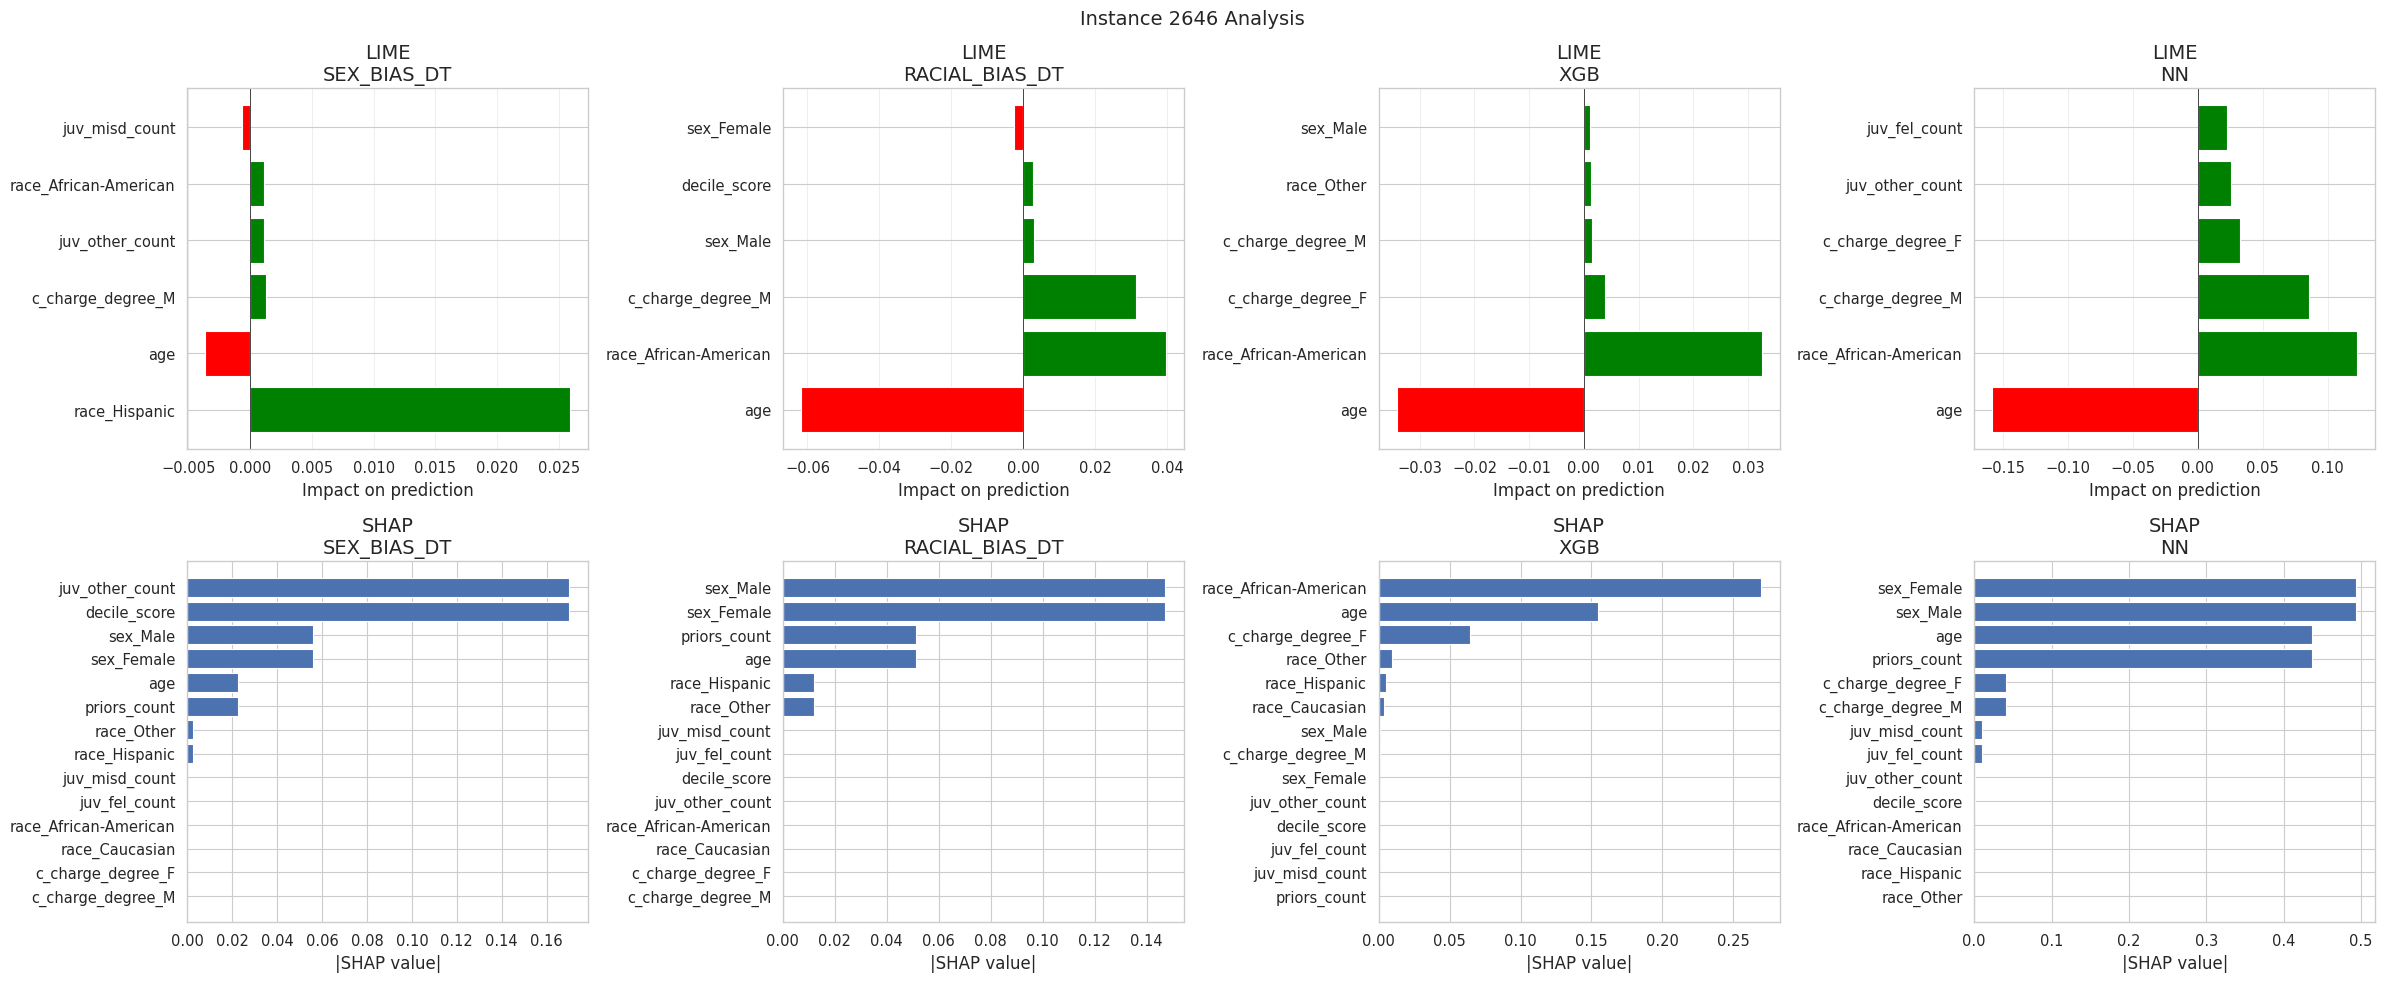


Instance 2844 (True label: No Recidivism)

Actual dataset values:
id                                                  1717
name                                       norence baker
first                                            norence
last                                               baker
compas_screening_date                         2013-09-06
sex                                                 Male
dob                                           1980-09-21
age                                                   35
age_cat                                          25 - 45
race                                    African-American
juv_fel_count                                          0
decile_score                                           6
juv_misd_count                                         0
juv_other_count                                        0
priors_count                                           5
days_b_screening_arrest                             -1.0
c_jail_in            

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda76b2a50>, 'local_exp': {1: [(np.int64(6), np.float64(0.04267035885347458)), (np.int64(0), np.float64(-0.00707399084565996)), (np.int64(3), np.float64(0.004191320275558658)), (np.int64(4), np.float64(0.002141538125141162)), (np.int64(10), np.float64(-0.002059367266857657)), (np.int64(12), np.float64(0.0018371925874152008))]}, 'intercept': {1: np.float64(0.3479801270174544)}, 'score': 0.2985108242575435, 'local_pred': array([0.48388137]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.66626038, 0.33373962])}
SHAP values shape: (1, 14, 2)
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda75971d0>, 'local_exp': {1: [(np.int64(0), np.float64(-0.06614905267504509)), (np.int64(4), np

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda7522960>, 'local_exp': {1: [(np.int64(4), np.float64(0.038155729997091714)), (np.int64(0), np.float64(-0.03664554407679196)), (np.int64(3), np.float64(0.0036365990361584342)), (np.int64(2), np.float64(0.0029967907976029113)), (np.int64(9), np.float64(-0.0012629028888236633)), (np.int64(10), np.float64(0.0006084489202004992))]}, 'intercept': {1: np.float64(0.5411279823816515)}, 'score': 0.6351033306978257, 'local_pred': array([0.46194426]), 'class_names': ['No Recidivism', 'Recidivism'], 'top_labels': None, 'predict_proba': array([0.61987936, 0.38012064], dtype=float32)}
SHAP values shape: (1, 14)
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
<class 'lime.explanation.Explanation'>
{'random_state': None, 'mode': 'classification', 'domain_mapper': <lime.lime_tabular.TableDomainMapper object at 0x7fdda67a0bf0>, 'local_exp': {1: [(np.int

  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
SHAP values shape: (1, 14, 2)


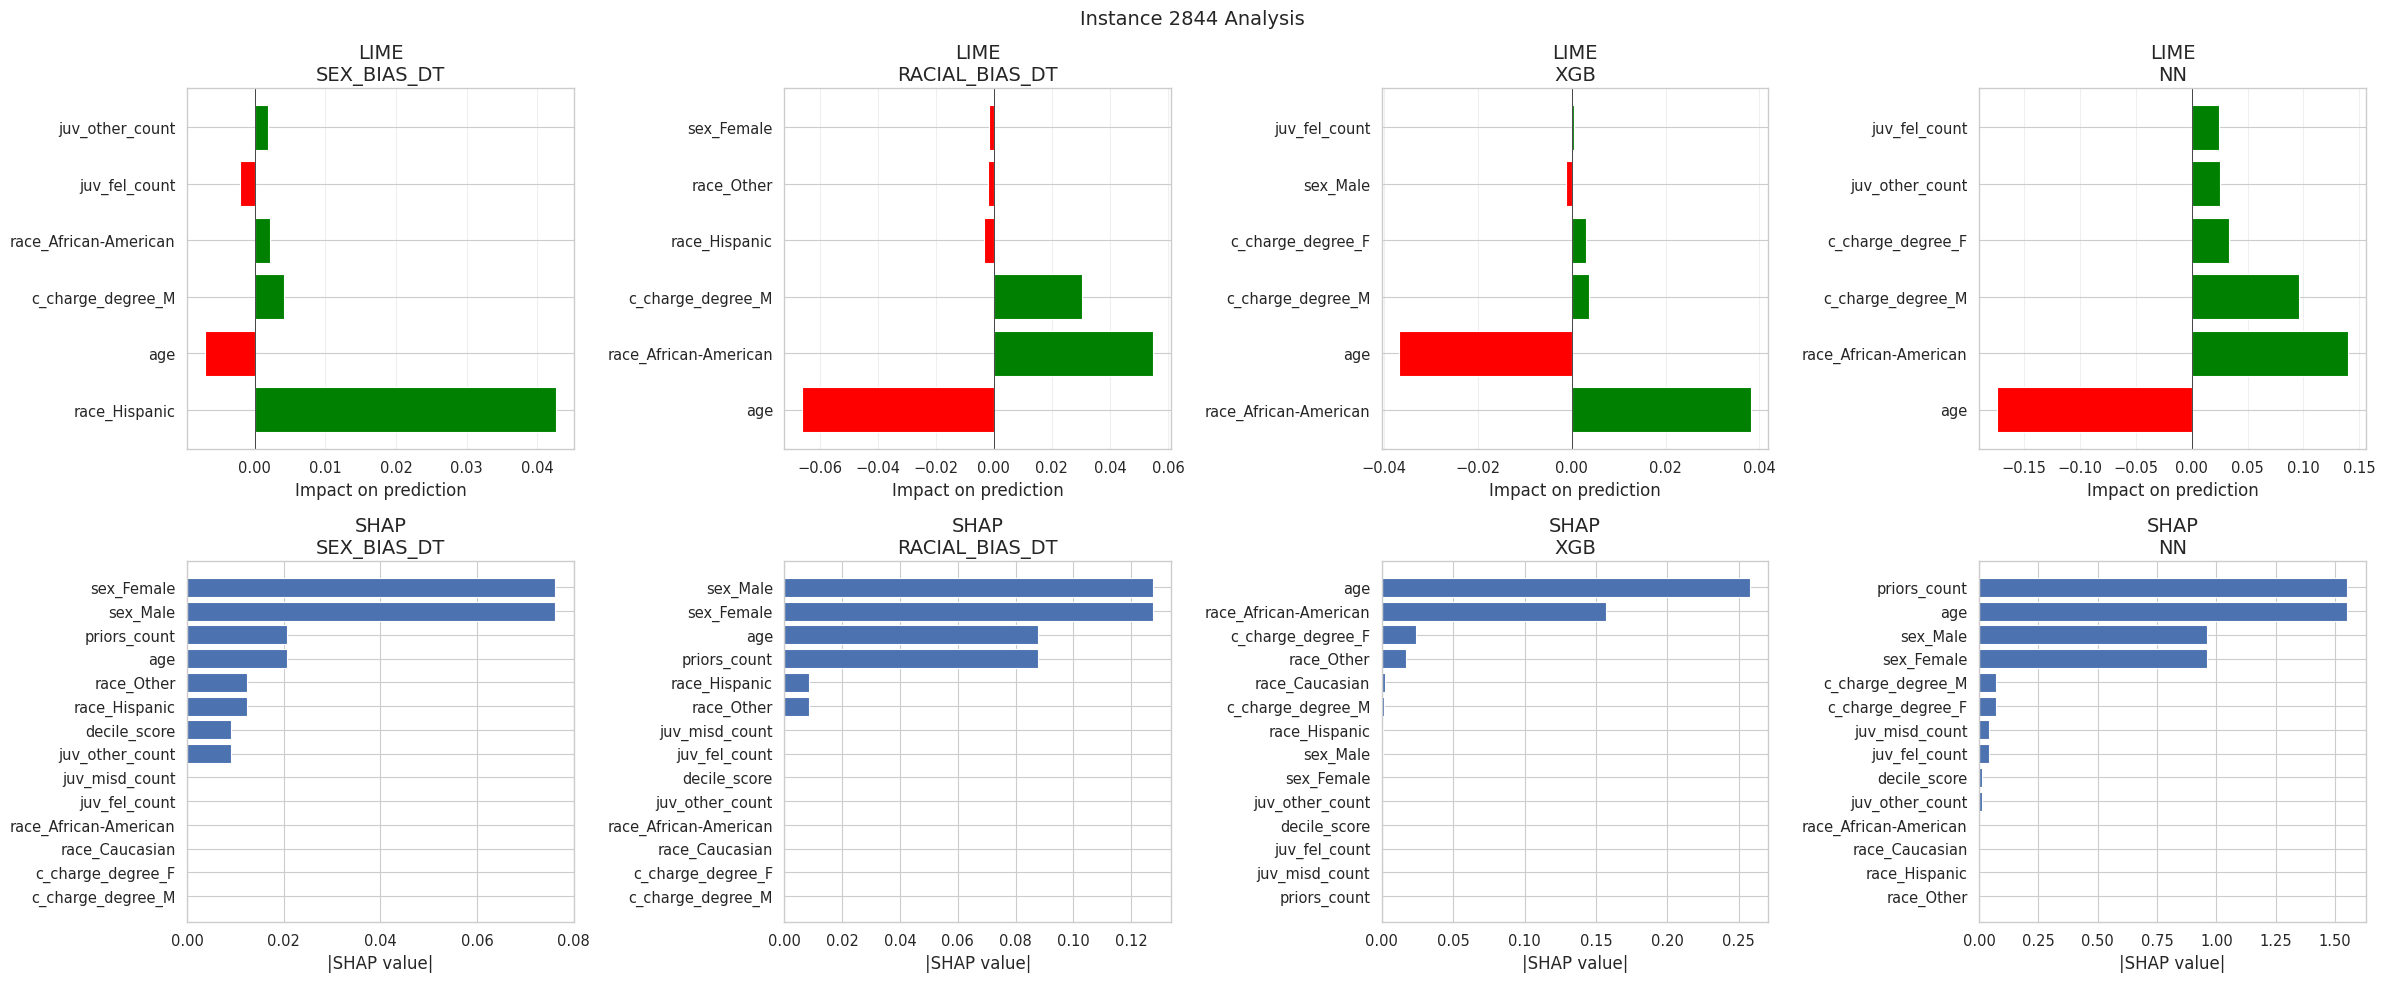

In [6]:
# Run LIME and SHAP Analysis

# Analyze random instances
print("\nAnalyzing 5 random instances...")
random_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in random_indices:
    instance = X_test.iloc[idx]
    true_label = y_test.iloc[idx]

    print("\n" + "="*80)
    print(f"Instance {idx} (True label: {'Recidivism' if true_label == 1 else 'No Recidivism'})")
    print("="*80)

    # Get predictions with proper type conversion
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)
    print("\nActual dataset values:")
    print(data.iloc[idx])
    # Get predictions for each model
    try:
        # For tree-based models, get probability of positive class
        sex_bias_pred = models_dict['sex_bias_dt'].predict_proba(instance_reshaped)[0, 1]
        racial_bias_pred = models_dict['racial_bias_dt'].predict_proba(instance_reshaped)[0, 1]
        xgb_pred = models_dict['xgb'].predict_proba(instance_reshaped)[0, 1]

        # For neural network, handle single output
        nn_output = models_dict['nn'].predict(instance_reshaped)
        if nn_output.shape[1] > 1:  # If multiple outputs (probabilities)
            nn_pred = nn_output[0, 1]  # Take probability of positive class
        else:  # If single output (logits/probability)
            nn_pred = nn_output[0, 0]  # Take the single value

        preds = {
            'sex_bias_dt': float(sex_bias_pred),
            'racial_bias_dt': float(racial_bias_pred),
            'xgb': float(xgb_pred),
            'nn': float(nn_pred)
        }

        print("\nDebug - Prediction shapes:")
        print(f"Sex Bias DT pred shape: {models_dict['sex_bias_dt'].predict_proba(instance_reshaped).shape}")
        print(f"Racial Bias DT pred shape: {models_dict['racial_bias_dt'].predict_proba(instance_reshaped).shape}")
        print(f"XGB pred shape: {models_dict['xgb'].predict_proba(instance_reshaped).shape}")
        print(f"NN pred shape: {nn_output.shape}")
    except Exception as e:
        print(f"Error getting predictions: {str(e)}")
        print(f"Shape of instance: {instance_reshaped.shape}")
        print(f"Neural network prediction shape: {models_dict['nn'].predict(instance_reshaped).shape}")
        raise

    # Print predictions
    print("\nPredictions:")
    print("-" * 40)
    for name, pred in preds.items():
        print(f"{name.upper():15} : {pred:.3f}")

    # Create figure for visualizations
    fig, axes = plt.subplots(2, 4, figsize=(24, 10))
    fig.suptitle(f'Instance {idx} Analysis', fontsize=14)

    # Get LIME explanations
    for i, (name, model) in enumerate(models_dict.items()):
        # Define prediction function based on model type
        if name == 'nn':
            # For neural network, wrap the prediction to match expected format
            def nn_predict_fn(x):
                pred = model.predict(x.astype(np.float32))
                if pred.shape[1] == 1:
                    # If single output, convert to two-class probability
                    return np.hstack([1 - pred, pred])
                return pred
            predict_fn = nn_predict_fn
        else:
            predict_fn = model.predict_proba

        # HERE IS WHERE THE MODEL IS BUILT
        exp = lime_exp.explain_instance(instance.values.astype(np.float32), predict_fn, num_features=6)
        print(type(exp))
        print(exp.__dict__)  # Shows internal parameters

        # Plot LIME explanation directly
        plt.sca(axes[0, i])
        exp_list = exp.as_list()
        features, values = zip(*exp_list)
        values = [float(v) for v in values]  # Convert to Python floats
        colors = ['green' if v > 0 else 'red' for v in values]
        y_pos = np.arange(len(features))

        # Create horizontal bar chart for LIME
        axes[0, i].barh(y_pos, values, align='center', color=colors)
        axes[0, i].set_yticks(y_pos)
        axes[0, i].set_yticklabels([str(x) for x in features])
        axes[0, i].set_xlabel('Impact on prediction')
        axes[0, i].set_title(f'LIME\n{name.upper()}')
        axes[0, i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[0, i].grid(True, axis='x', alpha=0.3)

        # Get SHAP values
        try:
            shap_values = shap_exp[name].shap_values(instance_reshaped)
            if isinstance(shap_values, list):
                print(f"SHAP values list length: {len(shap_values)}")
                for i, sv in enumerate(shap_values):
                    print(f"Shape of element {i}: {sv.shape if hasattr(sv, 'shape') else 'no shape'}")
            else:
                print(f"SHAP values shape: {shap_values.shape}")

            # Handle SHAP values based on model type
            if isinstance(shap_values, list):
                # For models that return a list of arrays (one per class)
                if len(shap_values) >= 2:
                    # Take positive class values
                    shap_array = shap_values[1]
                else:
                    # If only one array, use it
                    shap_array = shap_values[0]
            else:
                # For models that return a single array
                shap_array = shap_values

            # Ensure we have the right shape
            if isinstance(shap_array, np.ndarray):
                if shap_array.ndim > 2:
                    shap_array = shap_array.reshape(-1, len(feature_names))
                if shap_array.ndim == 2:
                    shap_array = shap_array[0]  # Take first instance

            # Ensure shap_array is 1D and matches feature_names length
            shap_array = np.array(shap_array).ravel()
            if len(shap_array) != len(feature_names):
                raise ValueError(f"SHAP values length ({len(shap_array)}) doesn't match feature count ({len(feature_names)})")

            # Create horizontal bar chart for SHAP
            plt.sca(axes[1, i])
            importance_values = np.abs(shap_array)

            # Sort by absolute importance
            sort_idx = np.argsort(importance_values)
            sorted_features = [feature_names[j] for j in sort_idx]
            sorted_importance = importance_values[sort_idx]
            y_pos = np.arange(len(sorted_features))

            # Create the plot
            axes[1, i].barh(y_pos, sorted_importance)
            axes[1, i].set_yticks(y_pos)
            axes[1, i].set_yticklabels(sorted_features)
            axes[1, i].set_title(f'SHAP\n{name.upper()}')
            axes[1, i].set_xlabel('|SHAP value|')

        except Exception as e:
            print(f"\nError calculating SHAP values for {name}: {str(e)}")
            # Fill the plot with a message
            axes[1, i].text(0.5, 0.5, 'SHAP values\nnot available',
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axes[1, i].transAxes)
            axes[1, i].set_title(f'SHAP\n{name.upper()}')

    plt.tight_layout()
    plt.show()


# Correlation Heatmap

106/157 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step
141/157 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step
 56/157 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step


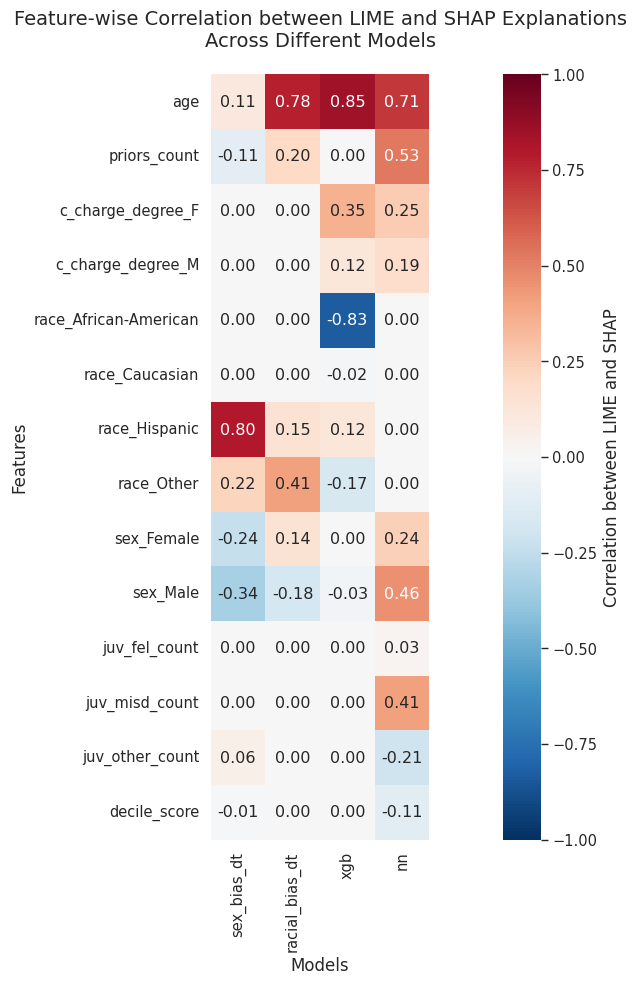


Summary of LIME vs SHAP Agreement by Feature:
--------------------------------------------------

Features ranked by consistency between LIME and SHAP:
age                       Mean correlation:  0.611 ± 0.340
race_Hispanic             Mean correlation:  0.270 ± 0.361 (Constant values in: NN)
priors_count              Mean correlation:  0.155 ± 0.281 (Constant values in: XGB)
c_charge_degree_F         Mean correlation:  0.151 ± 0.179 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT)
race_Other                Mean correlation:  0.115 ± 0.253 (Constant values in: NN)
juv_misd_count            Mean correlation:  0.103 ± 0.207 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB)
c_charge_degree_M         Mean correlation:  0.077 ± 0.093 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT)
sex_Female                Mean correlation:  0.036 ± 0.210 (Constant values in: XGB)
juv_fel_count             Mean correlation:  0.006 ± 0.013 (Constant values in: SEX_BIAS_DT, RACIAL_BIAS_DT, XGB)
race

In [7]:
# Create correlation heatmap between LIME and SHAP
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Initialize correlation matrices for each model
correlation_data = {}

def safe_correlation(x, y):
    """Calculate correlation with handling for constant arrays"""
    # Check if either array is constant
    if np.all(x == x[0]) or np.all(y == y[0]):
        if np.array_equal(x, y):  # If both arrays are identical constants
            return 1.0
        else:  # If only one array is constant or they're different constants
            return 0.0
    else:
        return stats.pearsonr(x, y)[0]

# Suppress specific warning about constant input
warnings.filterwarnings('ignore', category=stats.ConstantInputWarning)

# Select random instances for analysis
np.random.seed(42)  # for reproducibility
n_instances = 20
random_indices = np.random.choice(len(X_test), n_instances, replace=False)
test_instances = X_test.iloc[random_indices]

# Initialize storage for explanations
lime_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}
shap_explanations = {
    'sex_bias_dt': [], 'racial_bias_dt': [], 'xgb': [], 'nn': []
}

# Get explanations for each instance
for idx, instance in test_instances.iterrows():
    instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)

    # Get LIME explanations
    for name, model in models_dict.items():
        if name == 'nn':
            predict_fn = lambda x: np.hstack([1 - model.predict(x.astype(np.float32)),
                                          model.predict(x.astype(np.float32))])
        else:
            predict_fn = model.predict_proba

        exp = lime_exp.explain_instance(
            instance.values.astype(np.float32),
            predict_fn,
            num_features=len(feature_names)
        )
        lime_values = dict(exp.as_list())
        lime_explanations[name].append([lime_values.get(f, 0) for f in feature_names])

    # Get SHAP explanations
    for name, explainer in shap_exp.items():
        shap_values = explainer.shap_values(instance_reshaped)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = shap_values.reshape(-1)
        shap_explanations[name].append(shap_values)

# Convert explanations to numpy arrays
for name in models_dict.keys():
    lime_vals = np.abs(np.array(lime_explanations[name]))
    shap_vals = np.abs(np.array(shap_explanations[name]))

    # Calculate correlation for each feature
    correlations = []
    for i in range(len(feature_names)):
        corr = safe_correlation(lime_vals[:, i], shap_vals[:, i])
        correlations.append(corr)

    correlation_data[name] = correlations

# Create DataFrame with correlations
correlation_df = pd.DataFrame(correlation_data, index=feature_names)

# Create heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_df,
            cmap='RdBu_r',  # Red-Blue diverging colormap
            center=0,       # Center the colormap at 0
            vmin=-1,       # Minimum correlation
            vmax=1,        # Maximum correlation
            annot=True,    # Show correlation values
            fmt='.2f',     # Format for correlation values
            square=True,   # Make cells square
            cbar_kws={'label': 'Correlation between LIME and SHAP'})

plt.title('Feature-wise Correlation between LIME and SHAP Explanations\nAcross Different Models', pad=20)
plt.xlabel('Models')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Print summary statistics with additional information
print("\nSummary of LIME vs SHAP Agreement by Feature:")
print("-" * 50)

# Calculate mean correlation across models for each feature
mean_correlations = correlation_df.mean(axis=1)
std_correlations = correlation_df.std(axis=1)

# Sort features by average correlation
sorted_features = mean_correlations.sort_values(ascending=False)

print("\nFeatures ranked by consistency between LIME and SHAP:")
for feature in sorted_features.index:
    mean_corr = mean_correlations[feature]
    std_corr = std_correlations[feature]

    # Check if feature has any constant values
    constant_models = []
    for model in correlation_df.columns:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_models.append(model.upper())

    print(f"{feature:<25} Mean correlation: {mean_corr:6.3f} ± {std_corr:4.3f}", end="")
    if constant_models:
        print(f" (Constant values in: {', '.join(constant_models)})")
    else:
        print()

# Print model-wise statistics
print("\nModel-wise Agreement Statistics:")
print("-" * 50)
for model in correlation_df.columns:
    corrs = correlation_df[model]
    print(f"\n{model.upper()} Model:")
    print(f"Average correlation: {corrs.mean():.3f}")
    print(f"Correlation std: {corrs.std():.3f}")

    # Count features with constant values
    constant_features = []
    for feature in feature_names:
        lime_const = np.all(np.abs(lime_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(lime_explanations[model])[0, feature_names.index(feature)])
        shap_const = np.all(np.abs(shap_explanations[model])[:, feature_names.index(feature)] ==
                          np.abs(shap_explanations[model])[0, feature_names.index(feature)])
        if lime_const or shap_const:
            constant_features.append(feature)

    if constant_features:
        print(f"Features with constant values: {len(constant_features)}")
        print("Constant features:", ", ".join(constant_features))

    print(f"Features with highest agreement:")
    top_features = corrs.sort_values(ascending=False).head(3)
    for feat, corr in top_features.items():
        print(f"  {feat:<25} Correlation: {corr:.3f}")



# Flips

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
22/2

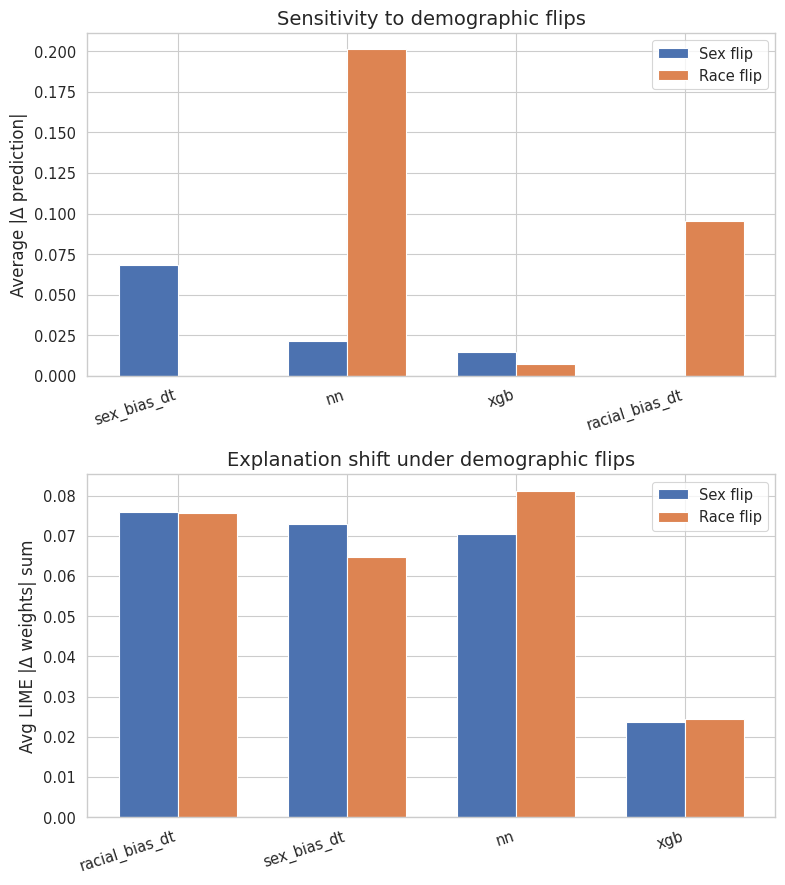


Prediction delta summary, sex flip:


,model,avg_delta,median_delta,std_delta,avg_abs_delta,p90_abs_delta
0,sex_bias_dt,-0.020003,0.006248,0.130914,0.068265,0.320746
1,nn,-0.009950,-0.010816,0.035336,0.021226,0.046948
2,xgb,-0.008246,-0.003298,0.016949,0.014451,0.029734
3,racial_bias_dt,0.000000,0.000000,0.000000,0.000000,0.000000



Prediction delta summary, race flip:


,model,avg_delta,median_delta,std_delta,avg_abs_delta,p90_abs_delta
0,sex_bias_dt,0.000000,0.000000,0.000000,0.000000,0.000000
1,nn,0.009815,-0.064478,0.274614,0.201351,0.555306
2,xgb,-0.001342,-0.000293,0.008171,0.007127,0.011479
3,racial_bias_dt,-0.031595,0.000000,0.116866,0.095672,0.173255



LIME attribution delta summary, sex flip:


,model,avg_lime_sumabs_delta,median_lime_sumabs_delta,std_lime_sumabs_delta,p90_lime_sumabs_delta
0,racial_bias_dt,0.075801,0.076392,0.021510,0.100037
1,sex_bias_dt,0.072887,0.071053,0.014358,0.089034
2,nn,0.070330,0.069312,0.017116,0.092976
3,xgb,0.023762,0.023307,0.004493,0.029654



LIME attribution delta summary, race flip:


,model,avg_lime_sumabs_delta,median_lime_sumabs_delta,std_lime_sumabs_delta,p90_lime_sumabs_delta
0,racial_bias_dt,0.075720,0.073741,0.015467,0.097663
1,sex_bias_dt,0.064721,0.066089,0.012979,0.079558
2,nn,0.081255,0.080044,0.020657,0.109502
3,xgb,0.024362,0.023352,0.005183,0.030116


In [8]:
# Fast counterfactual bias check across models, with aligned bar charts
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

def _2d(X): X=np.asarray(X); return X.reshape(1,-1) if X.ndim==1 else X
def _model_cols(m, fallback): return list(getattr(m, "feature_names_in_", list(fallback)))
def _to_df(X, cols): X=_2d(X); return pd.DataFrame(X, columns=cols if X.shape[1]==len(cols) else [f"c{i}" for i in range(X.shape[1])])
def _align(X, cols):
    X = _to_df(X, cols) if isinstance(X, (np.ndarray, list)) else pd.DataFrame(X).copy()
    for c in cols:
        if c not in X.columns: X[c]=0.0
    return X[cols]
def _proba(m, X, cols):
    Xa=_align(X, cols)
    if hasattr(m,"predict_proba"):
        p=m.predict_proba(Xa); p=np.asarray(p);
        return np.vstack([1-p, p]).T if p.ndim==1 else p
    if hasattr(m,"decision_function"):
        s=np.asarray(m.decision_function(Xa)).reshape(-1); p1=1/(1+np.exp(-s)); return np.vstack([1-p1,p1]).T
    y=np.asarray(m.predict(Xa)).reshape(-1).astype(float); y=np.clip(y,0,1); return np.vstack([1-y,y]).T
def _lime_fn(m, mcols, inc_cols):
    def fn(X):
        if isinstance(X,np.ndarray): X=_to_df(X, inc_cols)
        elif not isinstance(X,pd.DataFrame): X=_to_df(np.array(X), inc_cols)
        return _proba(m, X, mcols)
    return fn
def _pick_races(cols):
    r=[c for c in cols if c.startswith("race_")]
    if len(r)<2: return None
    return ("race_African-American","race_Caucasian") if {"race_African-American","race_Caucasian"}.issubset(r) else (r[0],r[1])
def flip_demo(X, kind="sex"):
    Xc=X.copy()
    if kind=="sex" and {"sex_Male","sex_Female"}.issubset(Xc.columns): Xc[["sex_Male","sex_Female"]]=Xc[["sex_Female","sex_Male"]].values
    if kind=="race":
        pair=_pick_races(Xc.columns)
        if pair: a,b=pair; Xc[a],Xc[b]=Xc[b].copy(),Xc[a].copy()
    return Xc

# -------- main --------
def compare_fast(X_test, models, lime_exp, feat_names, flip="sex", n=60, seed=42, kfeat=12, ksamples=700, only=None):
    rng=np.random.RandomState(seed); idx=rng.choice(len(X_test), size=min(n,len(X_test)), replace=False)
    Xo, Xc = X_test.iloc[idx].copy(), flip_demo(X_test.iloc[idx].copy(), kind=flip)
    inc_cols=list(X_test.columns)
    pred_rows, lime_rows, pair_rows = [], [], []
    items = [(k,v) for k,v in models.items() if (only is None or k in only)]
    for name, m in items:
        mcols=_model_cols(m, feat_names)
        p_o=_proba(m, Xo, mcols)[:,1]; p_c=_proba(m, Xc, mcols)[:,1]; d=p_c-p_o
        pred_rows.append({"model":name,"avg_delta":d.mean(),"median_delta":np.median(d),"std_delta":d.std(),"avg_abs_delta":np.abs(d).mean(),"p90_abs_delta":np.percentile(np.abs(d),90)})
        pf=_lime_fn(m, mcols, inc_cols); k=min(kfeat, len(inc_cols))
        d_l=[]; XoV, XcV = Xo.values, Xc.values
        for i in range(len(Xo)):
            eo=lime_exp.explain_instance(_2d(XoV[i]).ravel(), pf, num_features=k, num_samples=ksamples)
            ec=lime_exp.explain_instance(_2d(XcV[i]).ravel(), pf, num_features=k, num_samples=ksamples)
            def wd(e):
                dct={}
                for f,w in e.as_list():
                    key=f.split(" ")[0]; dct[key]=dct.get(key,0.0)+float(w)
                return dct
            do, dc = wd(eo), wd(ec); keys=set(do)|set(dc)
            s=float(np.sum([abs(do.get(t,0)-dc.get(t,0)) for t in keys])); d_l.append(s)
            pair_rows.append({"model":name,"row_index":int(idx[i]),"delta_pred":float(d[i]),"delta_lime_sumabs":s})
        lime_rows.append({"model":name,"avg_lime_sumabs_delta":np.mean(d_l),"median_lime_sumabs_delta":np.median(d_l),"std_lime_sumabs_delta":np.std(d_l),"p90_lime_sumabs_delta":np.percentile(d_l,90)})
    return (pd.DataFrame(pred_rows).sort_values("avg_abs_delta",ascending=False).reset_index(drop=True),
            pd.DataFrame(lime_rows).sort_values("avg_lime_sumabs_delta",ascending=False).reset_index(drop=True),
            pd.DataFrame(pair_rows))

# Run fast for sex and race
dfp_sex, dfl_sex, _ = compare_fast(X_test, models_dict, lime_exp, feature_names, flip="sex", n=60, seed=42, kfeat=12, ksamples=700)
dfp_race, dfl_race, _ = compare_fast(X_test, models_dict, lime_exp, feature_names, flip="race", n=60, seed=43, kfeat=12, ksamples=700)

# Align model order for bars
dfp_race = dfp_race.set_index("model").reindex(dfp_sex["model"]).reset_index()
dfl_race = dfl_race.set_index("model").reindex(dfl_sex["model"]).reset_index()

# Bar charts
labels=list(dfp_sex["model"]); x=np.arange(len(labels)); w=0.35
plt.figure(figsize=(max(8,len(labels)*1.1),9))
plt.subplot(2,1,1)
plt.bar(x-w/2, dfp_sex["avg_abs_delta"], w, label="Sex flip")
plt.bar(x+w/2, dfp_race["avg_abs_delta"], w, label="Race flip")
plt.xticks(x, labels, rotation=18, ha="right"); plt.ylabel("Average |Δ prediction|"); plt.title("Sensitivity to demographic flips"); plt.legend()
plt.subplot(2,1,2)
labels2=list(dfl_sex["model"]); x2=np.arange(len(labels2))
plt.bar(x2-w/2, dfl_sex["avg_lime_sumabs_delta"], w, label="Sex flip")
plt.bar(x2+w/2, dfl_race["avg_lime_sumabs_delta"], w, label="Race flip")
plt.xticks(x2, labels2, rotation=18, ha="right"); plt.ylabel("Avg LIME |Δ weights| sum"); plt.title("Explanation shift under demographic flips"); plt.legend()
plt.tight_layout(); plt.show()

print("\nPrediction delta summary, sex flip:"); display(dfp_sex)
print("\nPrediction delta summary, race flip:"); display(dfp_race)
print("\nLIME attribution delta summary, sex flip:"); display(dfl_sex)
print("\nLIME attribution delta summary, race flip:"); display(dfl_race)


# PCA vs. LIME

Analyzing LIME explanations with decision boundary context...

LIME Analysis for Random Instance 1 (Index: 3477)


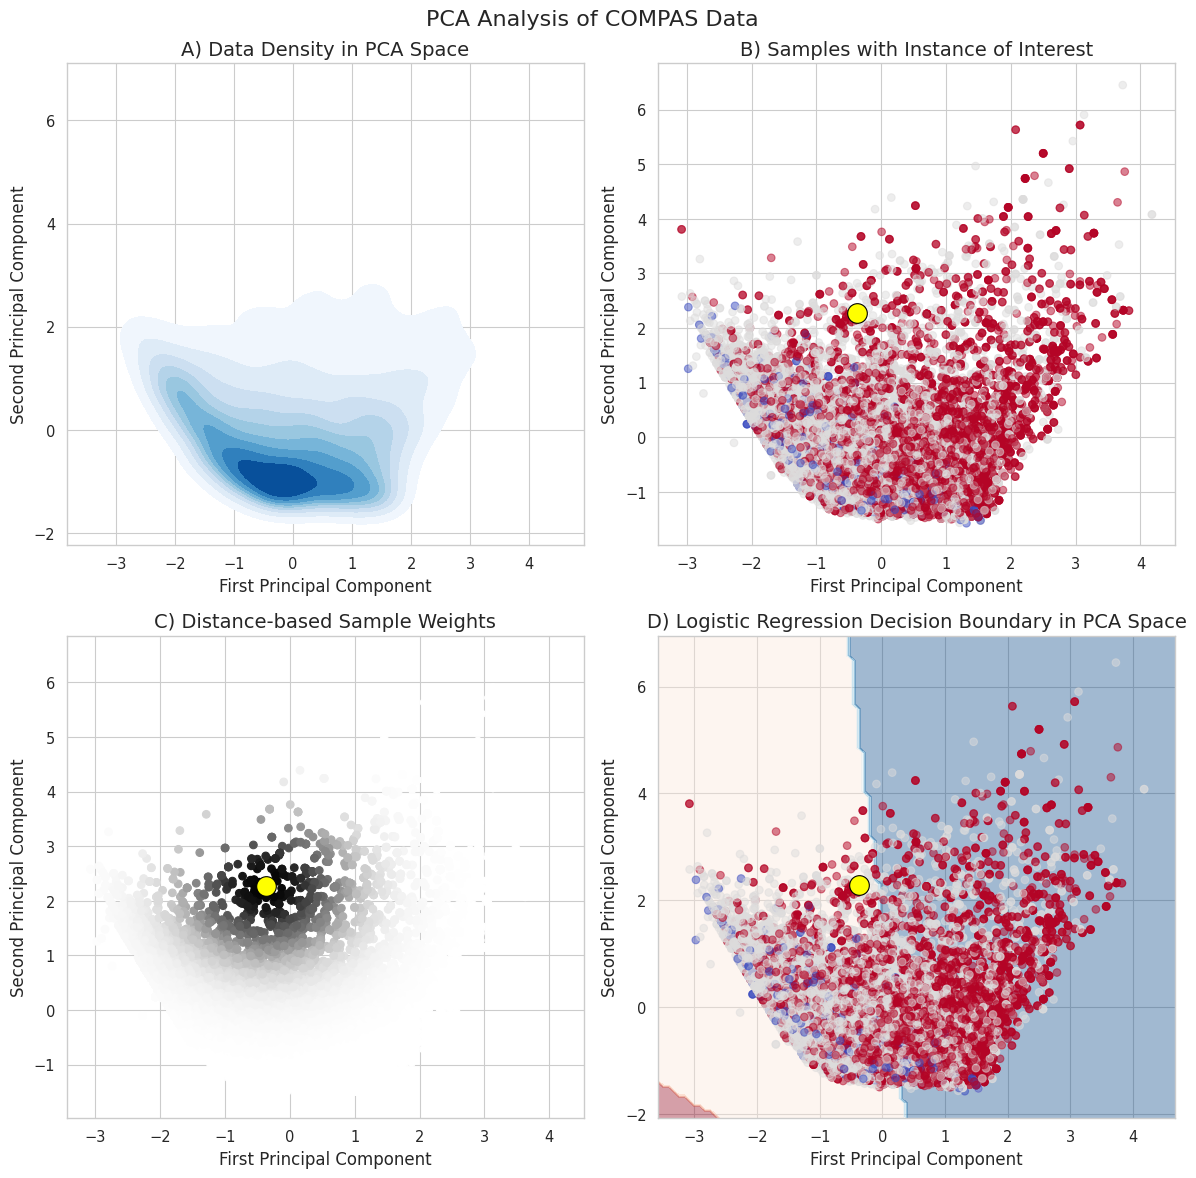


Explained variance ratio for first two components:
PC1: 0.3928 (39.3%)
PC2: 0.3015 (30.1%)

Detailed Analysis for Instance 3477:
------------------------------------------------------------

SEX_BIAS_DT Model:
  Predicted Label: No Recidivism
  Prediction Confidence: 66.00%
  Recidivism Probability: 0.340
  Top Contributing Features (LIME):
    1. race_Hispanic: 0.022 (towards recidivism)
    2. age: -0.003 (against recidivism)
    3. race_African-American: 0.001 (towards recidivism)
    4. juv_fel_count: -0.001 (against recidivism)
    5. priors_count: -0.001 (against recidivism)

RACIAL_BIAS_DT Model:
  Predicted Label: Recidivism
  Prediction Confidence: 62.40%
  Recidivism Probability: 0.624


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


  Top Contributing Features (LIME):
    1. age: -0.059 (against recidivism)
    2. race_African-American: 0.041 (towards recidivism)
    3. c_charge_degree_M: 0.029 (towards recidivism)
    4. race_Other: 0.003 (towards recidivism)
    5. juv_fel_count: -0.001 (against recidivism)

LIME Analysis for Random Instance 2 (Index: 3077)


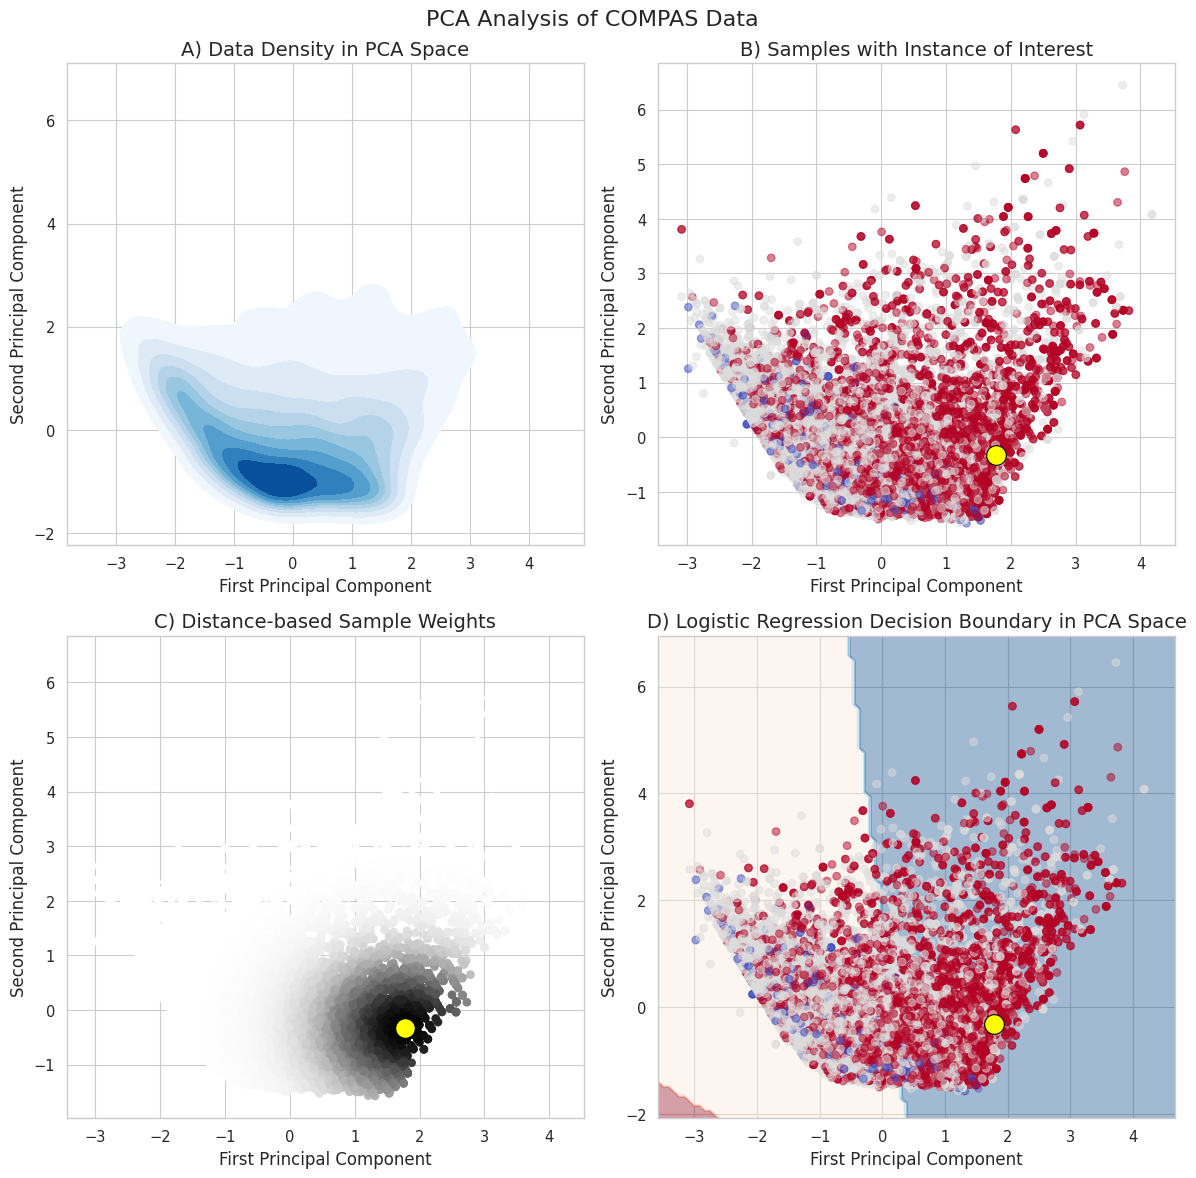


Explained variance ratio for first two components:
PC1: 0.3928 (39.3%)
PC2: 0.3015 (30.1%)

Detailed Analysis for Instance 3077:
------------------------------------------------------------

SEX_BIAS_DT Model:
  Predicted Label: No Recidivism
  Prediction Confidence: 66.00%
  Recidivism Probability: 0.340
  Top Contributing Features (LIME):
    1. race_Hispanic: 0.022 (towards recidivism)
    2. age: -0.002 (against recidivism)
    3. race_African-American: 0.002 (towards recidivism)
    4. c_charge_degree_F: 0.001 (towards recidivism)
    5. sex_Female: -0.001 (against recidivism)

RACIAL_BIAS_DT Model:
  Predicted Label: Recidivism
  Prediction Confidence: 62.40%
  Recidivism Probability: 0.624


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


  Top Contributing Features (LIME):
    1. age: -0.063 (against recidivism)
    2. race_African-American: 0.040 (towards recidivism)
    3. c_charge_degree_M: 0.028 (towards recidivism)
    4. sex_Male: -0.002 (against recidivism)
    5. race_Hispanic: -0.002 (against recidivism)


In [9]:
# LIME ANALYSIS FOR RANDOM INSTANCES WITH DECISION BOUNDARY CONTEXT

def analyze_lime_with_boundary_context(X_test, models_dict, lime_exp, feature_names, n_instances=3):
    """
    Analyze LIME explanations for random instances with decision boundary context
    """
    # Apply PCA to the full training data for visualization
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_train)

    # Create a grid for the prediction surface
    x1_min, x1_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
    x2_min, x2_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                          np.linspace(x2_min, x2_max, 100))

    # Select random instances
    random_indices = np.random.choice(len(X_test), n_instances, replace=False)

    for i, idx in enumerate(random_indices):
        instance = X_test.iloc[idx]

        print(f"\n{'='*80}")
        print(f"LIME Analysis for Random Instance {i+1} (Index: {idx})")
        print(f"{'='*80}")

        # Create figure with four subplots
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
        fig.suptitle('PCA Analysis of COMPAS Data', fontsize=16)

        # A) Data Density in PCA Space
        sns.kdeplot(data=pd.DataFrame(X_pca, columns=['PC1', 'PC2']),
                    x='PC1', y='PC2', fill=True, cmap='Blues',
                    ax=ax1)
        ax1.set_title('A) Data Density in PCA Space')

        # B) Instance of interest and samples
        scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                             cmap='coolwarm', alpha=0.5, s=30)
        # Highlight a random instance of interest
        instance_idx = np.random.randint(len(X_pca))
        ax2.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
                    color='yellow', s=200, marker='o', edgecolor='black')
        ax2.set_title('B) Samples with Instance of Interest')

        # C) Distance-based weights
        distances = np.sqrt(np.sum((X_pca - X_pca[instance_idx])**2, axis=1))
        weights = np.exp(-(distances**2)/2)
        scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=weights,
                             cmap='Greys', s=30)
        ax3.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
                    color='yellow', s=200, marker='o', edgecolor='black')
        ax3.set_title('C) Distance-based Sample Weights')

        # D) Decision boundary visualization
        # Train a simple model on PCA-transformed data to plot decision boundary
        from sklearn.linear_model import LogisticRegression
        model_pca = LogisticRegression(random_state=RANDOM_STATE)
        model_pca.fit(X_pca, y_train)

        # Predict on the grid points
        grid_points = np.c_[xx1.ravel(), xx2.ravel()]
        Z = model_pca.predict(grid_points)
        Z = Z.reshape(xx1.shape)

        # Plot decision boundary using the model's predictions on the grid
        ax4.contourf(xx1, xx2, Z, alpha=0.4, cmap='RdBu')
        ax4.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                   cmap='coolwarm', alpha=0.5, s=30)  # Plot original points
        ax4.scatter(X_pca[instance_idx, 0], X_pca[instance_idx, 1],
                   color='yellow', s=200, marker='o', edgecolor='black')  # Highlight instance
        ax4.set_title('D) Logistic Regression Decision Boundary in PCA Space')

        # Common settings for all subplots
        for ax in [ax1, ax2, ax3, ax4]:
            ax.set_xlabel('First Principal Component')
            ax.set_ylabel('Second Principal Component')
            ax.grid(True)

        plt.tight_layout()
        plt.show()

        # Print explained variance for first two components
        print("\nExplained variance ratio for first two components:")
        for j, var in enumerate(pca.explained_variance_ratio_, 1):
            print(f"PC{j}: {var:.4f} ({var*100:.1f}%)")

        # Get LIME explanations for both bias models
        models_to_analyze = {
            'sex_bias_dt': models_dict['sex_bias_dt'],
            'racial_bias_dt': models_dict['racial_bias_dt']
        }

        # Print detailed analysis
        print(f"\nDetailed Analysis for Instance {idx}:")
        print("-" * 60)

        for model_name, model in models_to_analyze.items():
            instance_reshaped = instance.values.reshape(1, -1).astype(np.float32)
            prediction_prob = model.predict_proba(instance_reshaped)[0, 1]
            prediction_label = "Recidivism" if prediction_prob > 0.5 else "No Recidivism"

            print(f"\n{model_name.upper()} Model:")
            print(f"  Predicted Label: {prediction_label}")
            print(f"  Prediction Confidence: {max(prediction_prob, 1-prediction_prob):.2%}")
            print(f"  Recidivism Probability: {prediction_prob:.3f}")

            # Get top LIME features
            predict_fn = lambda X: model.predict_proba(X)
            exp = lime_exp.explain_instance(
                instance.values.astype(np.float32),
                predict_fn,
                num_features=5
            )

            print(f"  Top Contributing Features (LIME):")
            for j, (feat, weight) in enumerate(exp.as_list()[:5], 1):
                direction = "towards" if weight > 0 else "against"
                print(f"    {j}. {feat}: {weight:.3f} ({direction} recidivism)")

# Run LIME analysis with boundary context
print("Analyzing LIME explanations with decision boundary context...")
analyze_lime_with_boundary_context(X_test, models_dict, lime_exp, feature_names, n_instances=2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


PCA variance: PC1=39.3%, PC2=30.1%

Instance 1: test index 10965


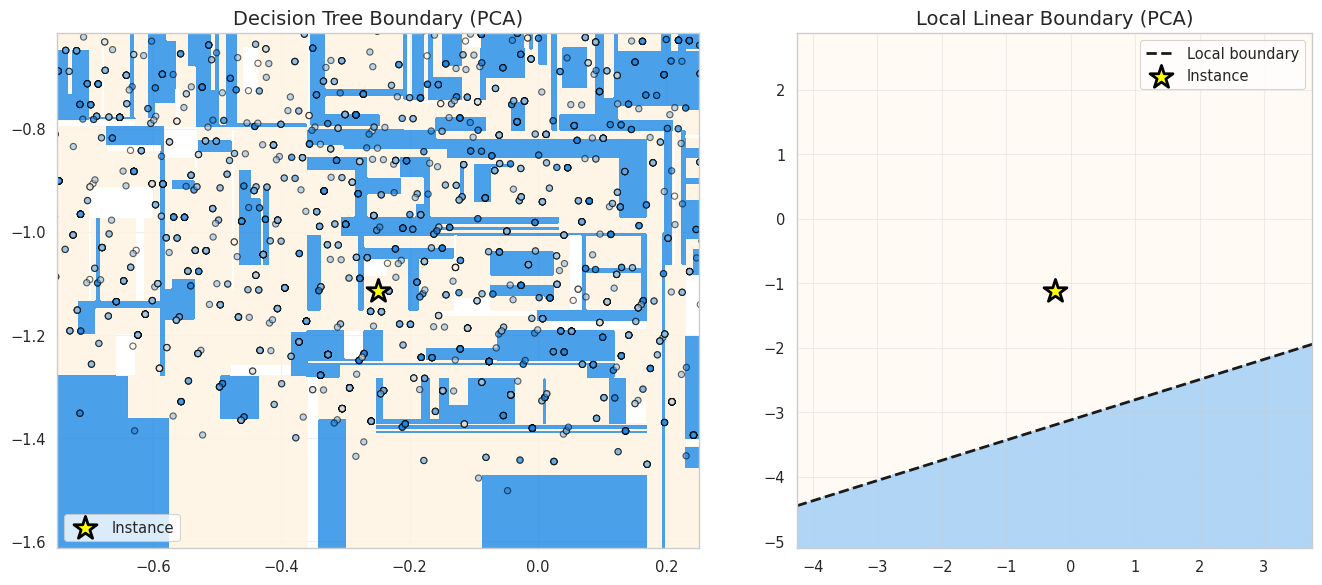


Instance 2: test index 8385


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


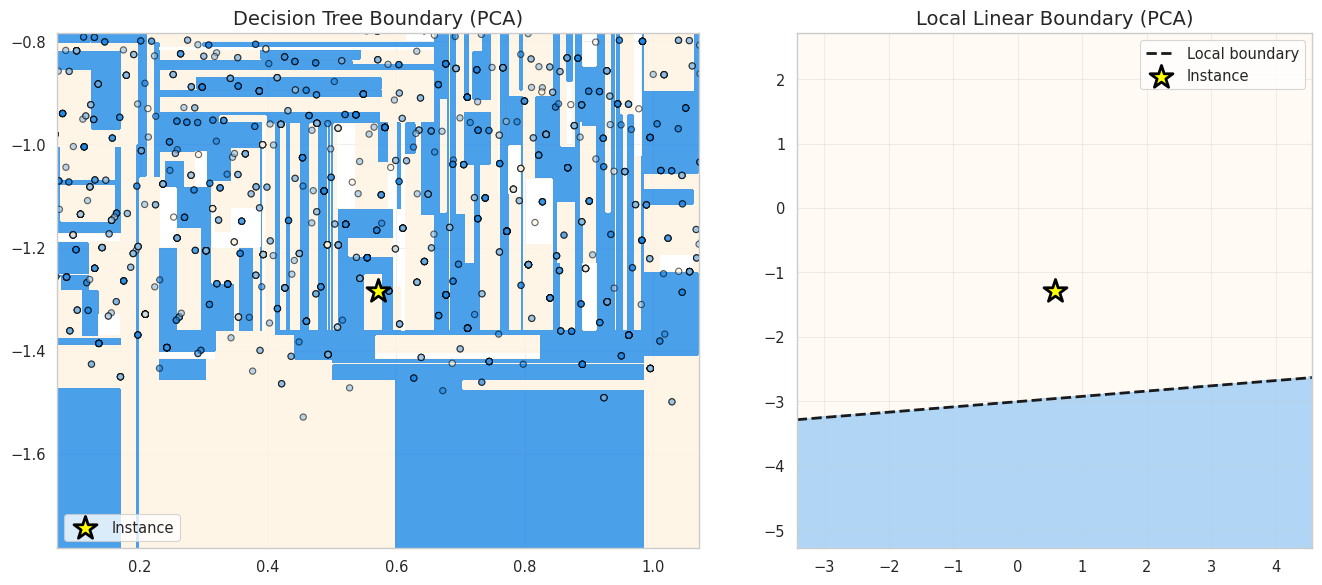


Instance 3: test index 17606


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


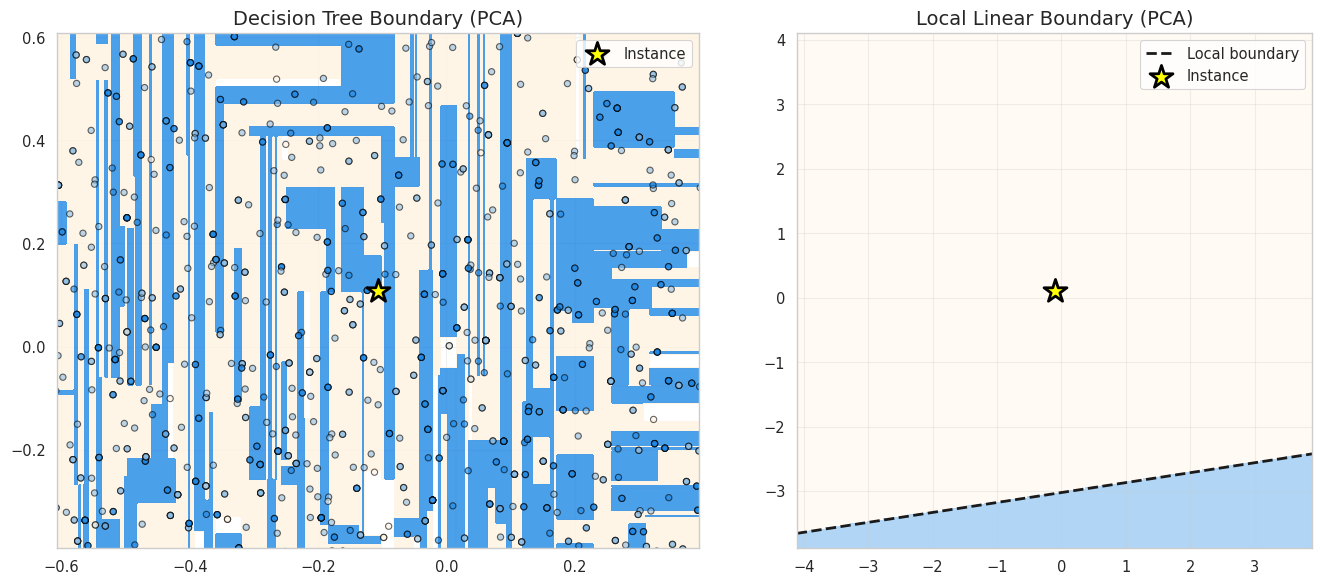

In [25]:
import numpy as np, warnings
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from lime import lime_tabular

# Assumes: X_train, y_train, X_test, y_test, feature_names, RANDOM_STATE exist.

def _pick_interesting_idxs(X, model, k=3):
    p = model.predict_proba(X)[:,1]
    return np.argsort(np.abs(p-0.5))[:k]

def _plot_dt(ax, X_train_pca, y_train, xlim, ylim):
    xx, yy = np.meshgrid(np.linspace(*xlim, 400), np.linspace(*ylim, 400))
    Z = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train_pca, y_train)\
        .predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    colors = ['#fff3e0', '#1e88e5']
    ax.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5], colors=colors, alpha=0.8)
    ax.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train,
               cmap=LinearSegmentedColormap.from_list('custom', colors),
               edgecolor='black', alpha=0.6, s=20)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title('Decision Tree Boundary (PCA)')
    ax.grid(True, alpha=0.3)

def _fit_local_logit_in_pca(model, pca, z_star, n=2000, radius=2.0):
    rng = np.random.RandomState(RANDOM_STATE)
    Z = z_star + rng.normal(size=(n,2)) * radius
    X = pca.inverse_transform(Z)
    y = model.predict(X)
    clf = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear').fit(Z, y)
    return clf.coef_[0], clf.intercept_[0]

def _plot_linear_boundary(ax, w, b, z_star, xlim, ylim):
    a, c = float(w[0]), float(w[1])
    xs = np.array([xlim[0], xlim[1]])
    if abs(c) > 1e-12:
        ys = (-(a*xs) - b)/c
    else:
        xs = np.full(2, -b/a); ys = np.array(ylim)
    ax.plot(xs, ys, 'k--', linewidth=2, label='Local boundary')
    ax.scatter(*z_star, color='yellow', marker='*', s=300, edgecolor='black', linewidth=2, label='Instance')
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3); ax.legend(loc='best')

def _shade_halfplane(ax, w, b, xlim, ylim):
    xx, yy = np.meshgrid(np.linspace(*xlim, 400), np.linspace(*ylim, 400))
    mask = (w[0]*xx + w[1]*yy + b) > 0   # 1=Recidivism side
    arr = mask.astype(int)               # numeric 0/1 for imshow
    cmap = ListedColormap(['#fff3e0', '#1e88e5'])
    ax.imshow(arr, extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
              origin='lower', cmap=cmap, alpha=0.35, vmin=0, vmax=1, interpolation='nearest')

def _plot_local_panel(ax, model, pca, z_star, xlim, ylim, local_radius=2.0):
    w, b = _fit_local_logit_in_pca(model, pca, z_star, radius=local_radius)
    _shade_halfplane(ax, w, b, xlim, ylim)
    _plot_linear_boundary(ax, w, b, z_star, xlim, ylim)
    ax.set_title('Local Linear Boundary (PCA)')

def compare_instance(idx, X_test, y_test, model, pca, X_train_pca,
                     zoom_dt=1.8, zoom_lime=1.8, local_radius=2.0):
    x = X_test.iloc[idx].values
    z = pca.transform(x.reshape(1, -1))[0]
    xlim_dt  = (z[0]-zoom_dt,  z[0]+zoom_dt)
    ylim_dt  = (z[1]-zoom_dt,  z[1]+zoom_dt)
    xlim_lm  = (z[0]-zoom_lime, z[0]+zoom_lime)
    ylim_lm  = (z[1]-zoom_lime, z[1]+zoom_lime)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
    _plot_dt(ax1, X_train_pca, y_train, xlim_dt, ylim_dt)
    ax1.scatter(*z, color='yellow', marker='*', s=300, edgecolor='black', linewidth=2, zorder=5, label='Instance')
    ax1.legend(loc='best')
    _plot_local_panel(ax2, model, pca, z, xlim_lm, ylim_lm, local_radius=local_radius)
    plt.tight_layout(); return fig

def analyze_instances(X_test, y_test, model, pca,
                      k=3, zoom_dt=1.8, zoom_lime=1.8, pick='interesting', local_radius=2.0):
    Xtr = X_train.values if hasattr(X_train, "values") else np.asarray(X_train)
    X_train_pca = pca.transform(Xtr)
    print(f"PCA variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
    idxs = _pick_interesting_idxs(X_test.values, model, k) if pick=='interesting' \
           else np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=k, replace=False)
    for r, idx in enumerate(idxs, 1):
        print(f"\nInstance {r}: test index {X_test.index[idx]}")
        compare_instance(idx, X_test, y_test, model, pca, X_train_pca,
                         zoom_dt=zoom_dt, zoom_lime=zoom_lime, local_radius=local_radius)
        plt.show()

# Train once here
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train)
explainer = lime_tabular.LimeTabularExplainer(  # not used for shading, kept if you still want tabular outputs elsewhere
    (X_train.values if hasattr(X_train, "values") else np.asarray(X_train)),
    feature_names=feature_names,
    class_names=['No Recidivism','Recidivism'],
    mode='classification',
    discretize_continuous=False
)

# Independent zooms; crisp linear boundary + numeric shading (no dtype errors)
analyze_instances(X_test, y_test, dt_model, pca2,
                  k=3, zoom_dt=0.5, zoom_lime=4, pick='interesting', local_radius=2.0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from lime import lime_tabular
import seaborn as sns
from scipy.interpolate import griddata # Import griddata
import warnings
from sklearn.utils import validation # Import validation module to filter warning


def analyze_lime_trust(X_train, y, dt_model, lime_explainer, pca, feature_names, n_points=500):
    """Analyze LIME trustworthiness vs decision tree boundaries in PCA space"""
    X_pca = pca.transform(X_train)
    np.random.seed(42)
    indices = np.random.choice(len(X_train), n_points, replace=False)

    metrics = {'scores': [], 'distances': [], 'points': []}

    for idx in indices:
        point = X_train.iloc[idx].values # Access point using iloc and get values, convert to numpy array
        point_pca = X_pca[idx]
        # Suppress the UserWarning about feature names for this explanation
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.utils.validation')
            exp = lime_explainer.explain_instance(point, dt_model.predict_proba, num_features=X_train.shape[1])

        # Correctly extract LIME coefficients
        lime_exp_list = exp.as_list()
        lime_coef_dict = {feat: weight for feat, weight in lime_exp_list}
        # Map LIME coefficients to match feature_names order for projection
        lime_coef_ordered = np.array([lime_coef_dict.get(name, 0) for name in feature_names])


        # Sample points in a circle around the instance in PCA space
        # Generate points in the original feature space for prediction
        theta = np.linspace(0, 2*np.pi, 50)
        radius = 0.5 # Radius in PCA space for sampling
        surrounding_pca = np.column_stack([point_pca[0] + radius * np.cos(theta),
                                         point_pca[1] + radius * np.sin(theta)])

        # Inverse transform surrounding points from PCA space to original feature space
        try:
            surrounding_original = pca.inverse_transform(surrounding_pca)
        except Exception as e:
             print(f"Warning: Could not inverse transform points for instance {idx}: {e}")
             continue # Skip this instance if inverse transform fails

        # LIME local prediction sign is based on the dot product
        lime_preds = np.sign(np.dot(relative_points_original, lime_coef_ordered))
        # Convert -1, 0, 1 to 0, 1
        lime_preds = (lime_preds > 0).astype(int) # Positive dot product -> class 1


        # Actual DT predictions for the surrounding points
        # Suppress the UserWarning about feature names for this prediction
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.utils.validation')
            actual_preds = dt_model.predict(surrounding_original)

        # Calculate agreement score
        metrics['scores'].append(np.mean(actual_preds == lime_preds))

        direction_pca = np.dot(lime_coef_ordered, pca.components_.T)
        # Normalize the direction vector for distance calculation
        norm_direction_pca = np.linalg.norm(direction_pca)

        if norm_direction_pca > 1e-6: # Avoid division by zero

            # A simpler interpretation: How far are points from the instance that LIME and DT disagree on?
            # Let's calculate the average distance in PCA space to points where LIME and DT disagree
            disagreement_indices = np.where(actual_preds != lime_preds)[0]
            if len(disagreement_indices) > 0:
                disagreement_points_pca = surrounding_pca[disagreement_indices]
                distances_to_instance_pca = np.linalg.norm(disagreement_points_pca - point_pca, axis=1)
                # Use the mean distance to disagreement points as a metric
                metrics['distances'].append(np.mean(distances_to_instance_pca))
            else:
                # If no disagreements, assign a maximum distance or None
                metrics['distances'].append(radius) # Or some other large value / indicator

        else:
             # If LIME coefficients are all zero, no clear boundary direction
             metrics['distances'].append(np.nan) # Indicate no meaningful distance


        metrics['points'].append(point_pca)

    return metrics


def plot_trust_analysis(metrics, X_pca):
    """Visualize trust analysis results"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    scores = np.array(metrics['scores'])
    distances = np.array(metrics['distances']) # Now includes NaNs

    # Agreement score distribution
    axes[0,0].hist(scores, bins=20)
    axes[0,0].set(title='LIME Agreement Scores (Local Samples)', xlabel='Score', ylabel='Count')

    # Score vs boundary distance (only for points with valid distance)
    valid_indices = ~np.isnan(distances)
    if np.sum(valid_indices) > 0:
        axes[0,1].scatter(distances[valid_indices], scores[valid_indices], alpha=0.5)
        axes[0,1].set(title='Agreement vs Avg Disagreement Distance',
                     xlabel='Avg Distance to Disagreement (PCA)', ylabel='Score')
    else:
         axes[0,1].text(0.5, 0.5, 'No valid distances\n(e.g., no disagreements)',
                          horizontalalignment='center', verticalalignment='center',
                          transform=axes[0,1].transAxes)
         axes[0,1].set_title('Agreement vs Avg Disagreement Distance')


    # Trust heatmap
    points = np.array(metrics['points'])
    # Only use points with valid scores for interpolation
    points_valid = points[valid_indices]
    scores_valid = scores[valid_indices]

    if len(points_valid) > 1: # griddata requires at least 2 points
        xi = np.linspace(points[:,0].min(), points[:,0].max(), 50)
        yi = np.linspace(points[:,1].min(), points[:,1].max(), 50)
        zi = griddata(points_valid, scores_valid, (xi[None,:], yi[:,None]), method='cubic') # Use valid points
        im = axes[1,0].imshow(zi, extent=[xi.min(), xi.max(), yi.min(), yi.max()],
                             origin='lower', cmap='RdYlGn', aspect='auto')
        plt.colorbar(im, ax=axes[1,0])
        axes[1,0].set(title='Trust Score Heatmap (Interpolated)', xlabel='PCA1', ylabel='PCA2')
    else:
         axes[1,0].text(0.5, 0.5, 'Not enough valid points\nfor heatmap interpolation',
                          horizontalalignment='center', verticalalignment='center',
                          transform=axes[1,0].transAxes)
         axes[1,0].set_title('Trust Score Heatmap (Interpolated)')


    # Data points colored by trust
    # Use X_train_pca for the background points
    global pca
    X_train_pca_all = pca.transform(X_train)

    scatter = axes[1,1].scatter(X_train_pca_all[:,0], X_train_pca_all[:,1], c='lightgrey',
                               alpha=0.3, s=10) # Plot all training points as background

    # Overlay the analyzed points colored by trust score
    if len(points) > 0:
        scatter_analyzed = axes[1,1].scatter(points[:,0], points[:,1], c=scores,
                                   cmap='RdYlGn', alpha=0.8, s=50, edgecolors='black', linewidth=0.5)
        plt.colorbar(scatter_analyzed, ax=axes[1,1], label='LIME Agreement Score')


    axes[1,1].set(title='Trust Scores at Sampled Instances (PCA Space)', xlabel='PCA1', ylabel='PCA2')


    plt.tight_layout()
    plt.show()

    print(f"\nTrust Analysis Summary:")
    print(f"Mean Score: {scores.mean():.3f} (±{scores.std():.3f})")
    print(f"Range: [{scores.min():.3f}, {scores.max():.3f}]")
    if len(scores) > 0:
        print(f"High-trust regions (>0.8 score): {(scores > 0.8).mean()*100:.1f}% of sampled instances")
    else:
        print("No sampled instances analyzed.")


# Train a Decision Tree model on the training data
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train) # Fit with X_train (DataFrame with feature names)
print("Decision Tree model trained.")

# Fit PCA on the training data
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
print(f"PCA fitted on X_train. Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")


# Create LIME explainer using the training data
explainer = lime_tabular.LimeTabularExplainer(
    X_train.values, # Use numpy array of training data
    feature_names=feature_names,
    class_names=['No Recidivism', 'Recidivism'], # Use meaningful class names
    mode='classification',
    discretize_continuous=False # Data is already normalized
)
print("LIME explainer initialized.")

# Run analysis
print("Starting LIME Trust Analysis...")
metrics = analyze_lime_trust(X_train, y_train, dt_model, explainer, pca, feature_names) # Pass explainer, use X_train, y_train, and feature_names
plot_trust_analysis(metrics, pca.transform(X_test)) # Use X_test for background plot points
print("\nAnalysis complete.")